# DATA266 Lab 1 · Task 3: CycleGAN for Monet ↔ Photo translation (member: parth)

This notebook is the canonical implementation for Task 3. It contains the data pipeline, generator, discriminator, losses, training loop, diagnostics, checkpointing and inference, together with the recorded results of the six full-scale experiments EXP-00 to EXP-05 and the implementation of EXP-06.

**Running it.** Open it with the project environment (Python 3.12, PyTorch 2.11 with CUDA) from anywhere inside the repository. The repository root is found automatically and every path is repository-relative. With the default `RUN_MODE = "smoke"` the notebook:

* runs a 6-step training smoke test in a temporary folder, so nothing is written into the repository;
* loads the EXP-05 checkpoints with strict loading;
* regenerates 16 + 16 of EXP-05's evaluated predictions and compares them byte for byte with the evaluated files (the saved result is in Section 14);
* shows the recorded results.

`RUN_MODE = "full"` trains the 60-epoch baseline from scratch (about 1.5 h on an RTX 5090). It runs only if it is set explicitly.

**Relationship to the recorded runs.** EXP-00 to EXP-05 were trained with a standalone command-line script, `src/train.py`, which also wrote the raw logs, manifests and run index. The training loop in this notebook implements the same model and algorithm. Sections 13 and 14 show that the notebook's classes load the EXP-05 checkpoint with `strict=True` and reproduce its recorded predictions byte for byte.

**Evaluation.** This notebook does not compute FID, KID, LPIPS or any other metric. Section 15 loads and reports the saved results of the external evaluators.

| # | Section | # | Section |
|---|---|---|---|
| 1 | Project overview | 12 | Training diagnostics |
| 2 | Task constraints and design choices | 13 | Checkpoint loading |
| 3 | Environment and reproducibility | 14 | Inference |
| 4 | Dataset | 15 | Evaluation |
| 5 | Baseline configuration | 16 | Historical experiments |
| 6 | Generator | 17 | Current best result |
| 7 | Discriminator | 18 | Failure analysis |
| 8 | Loss functions | 19 | Visual results |
| 9 | CycleGAN assembly | 20 | Reproducibility |
| 10 | Optimizers and LR schedule | 21 | Final discussion |
| 11 | Training loop | 22 | EXP-06: gated additive U-Net skip connections (implemented; run later, internal results only) |

Sections 1 to 21 cover the baseline and the recorded experiments EXP-00 to EXP-05. Section 22 documents and validates EXP-06, which was run after this notebook's saved session; only its internal evaluation summary survives in the packaged files, so EXP-05 remains the final reported model.

## 1. Project overview

**Task.** Unpaired image-to-image translation between two domains:

* **Domain A:** 300 Monet paintings.
* **Domain B:** 7,038 landscape photographs.

All images are 256×256 RGB JPEGs. No photo has a "matching" painting, so supervised (paired) training is impossible.

**Objective (Task 3).** Train a CycleGAN from scratch that translates in both directions:

* `G_A2B`: Monet → photo
* `G_B2A`: photo → Monet, the direction used by the class competition

The outputs are evaluated with the course evaluator (FID and the course "MiFID" in both directions) and with a separate local evaluator (FID, KID, precision/recall, LPIPS and others).

**CycleGAN formulation** (Zhu et al., 2017). Two generators, $G: A\to B$ (`G_A2B`) and $F: B\to A$ (`G_B2A`), are trained against two discriminators. $D_B$ judges whether a photo is real or generated, and $D_A$ does the same for Monet paintings. The adversarial losses alone would allow any mapping that produces the right *style*. The **cycle-consistency** constraint $F(G(a))\approx a$ and $G(F(b))\approx b$ forces each translation to keep enough of the input's content to be reversible. An **identity** term ($F(a)\approx a$, $G(b)\approx b$) discourages unnecessary colour shifts.

**Project goals.**

1. A faithful, well-documented implementation of the paper's recipe (EXP-00).
2. Controlled, single-change experiments that test specific hypotheses (EXP-01 to EXP-04), plus a replicate (EXP-05) to estimate run-to-run variation.
3. Negative results reported alongside the positive ones.

## 2. Task constraints and design choices

The implementation follows these constraints from the lab and the class competition.

* **Data.** Training reads only `task3_gan/data/monet_jpg/` (300 images) and `task3_gan/data/photo_jpg/` (7,038 images). `UnpairedDataset` draws independent per-epoch permutations for A and B, so no fixed (Monet, photo) pairing exists.
* **Networks and losses.** Two ResNet-9 generators (`G_A2B`, `G_B2A`) and two 70×70 PatchGAN discriminators (`D_A`, `D_B`), with an LSGAN adversarial loss and an L1 cycle-consistency loss of weight 10 in both directions.
* **Training from scratch.** All four networks start from N(0, 0.02) weights. No pretrained weights are loaded into a generator or a discriminator.
* **Predictions.** Each output is one forward pass of the trained generator, saved as a JPEG with no post-processing, filtering or selection. The course evaluator pairs real image *i* with generated image *i* by sorted index. Outputs are named after their own input and written in sorted input order, and nothing reorders or selects outputs to influence that pairing.
* **Pretrained networks.** The only pretrained networks are the feature extractors used for evaluation: Inception-v3 for FID and KID, and AlexNet for LPIPS. They never produce or modify an image.

## 3. Environment and reproducibility

The cell below finds the repository root, sets the run mode and seed, and records the software and hardware. **The seed is configurable**: change `SEED`, or set the environment variable `TASK3_SEED`. The official full-run seed is **8503** (EXP-00 to EXP-05).

In [1]:
import os, sys, json, math, time, copy, random, hashlib, itertools, platform, tempfile, re, csv
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import make_grid, save_image
from PIL import Image, UnidentifiedImageError
from IPython.display import display, Markdown

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)


def find_repo_root(start=None) -> Path:
    """Walk up from the current folder to the repository root (the folder that contains task3_gan/)."""
    here = Path(start or Path.cwd()).resolve()
    for cand in (here, *here.parents):
        if (cand / "task3_gan" / "data").is_dir() and (cand / "task3_gan" / "parth").is_dir():
            return cand
    raise FileNotFoundError("Open this notebook from inside the repository (the folder that contains task3_gan/).")


REPO = find_repo_root()
MEMBER = REPO / "task3_gan" / "parth"
DATA = REPO / "task3_gan" / "data"


def rel(p) -> str:
    """Repository-relative display path (this notebook never prints absolute paths)."""
    p = Path(p).resolve()
    try:
        return p.relative_to(REPO).as_posix()
    except ValueError:
        return f"<outside the repository>/{p.name}"


# ---- Run settings: edit these lines (or set the environment variables) before "Run All". ----
RUN_MODE = os.environ.get("TASK3_RUN_MODE", "smoke").lower()  # "none" | "smoke" (default, minutes) | "full" (60 epochs)
SEED = int(os.environ.get("TASK3_SEED", "8503"))              # official full-run seed: 8503
assert RUN_MODE in {"none", "smoke", "full"}, RUN_MODE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def set_seed(seed: int) -> None:
    """Seed Python, NumPy and PyTorch (CPU and every GPU)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def configure_backends(allow_tf32: bool = True, cudnn_benchmark: bool = True) -> dict:
    """Training numerics of every recorded run: cuDNN autotuner on, TF32 tensor cores for FP32 convs/matmuls."""
    if not torch.cuda.is_available():
        return {"cuda": False}
    torch.backends.cudnn.benchmark = cudnn_benchmark
    torch.backends.cudnn.deterministic = False
    mode = "tf32" if allow_tf32 else "ieee"
    conv = getattr(torch.backends.cudnn, "conv", None)
    if hasattr(torch.backends.cuda.matmul, "fp32_precision") and hasattr(conv, "fp32_precision"):
        torch.backends.cuda.matmul.fp32_precision = mode   # PyTorch >= 2.9 API
        torch.backends.cudnn.conv.fp32_precision = mode
    else:
        torch.backends.cuda.matmul.allow_tf32 = allow_tf32
        torch.backends.cudnn.allow_tf32 = allow_tf32
    return {"cuda": True, "cudnn_benchmark": cudnn_benchmark, "tf32": allow_tf32}


gpu = torch.cuda.get_device_properties(0) if torch.cuda.is_available() else None
env = {
    "Python": platform.python_version(),
    "PyTorch": torch.__version__,
    "torchvision": torchvision.__version__,
    "CUDA build": torch.version.cuda,
    "cuDNN": torch.backends.cudnn.version() if torch.cuda.is_available() else None,
    "GPU": f"{gpu.name} ({gpu.total_memory / 2**30:.1f} GB)" if gpu else "none (CPU only)",
    "Device used": str(DEVICE),
    "OS": f"{platform.system()} {platform.release()}",
    "Run mode": RUN_MODE,
    "Seed": SEED,
    "Image size / batch size": "256 x 256 RGB / 1",
    "Optimizer / scheduler": "Adam (0.5, 0.999), LR 2e-4 / constant 30 epochs + linear decay 30 epochs",
}
display(pd.DataFrame(list(env.items()), columns=["item", "value"]).set_index("item"))

,value
item,
Python,3.12.10
PyTorch,2.11.0+cu130
torchvision,0.26.0+cu130
CUDA build,13.0
cuDNN,91900
GPU,NVIDIA GeForce RTX 5090 (31.8 GB)
Device used,cuda
OS,Windows 11
Run mode,smoke


**What the seed controls.**

* The initial weights of all four networks.
* The per-epoch A/B index permutations.
* The DataLoader's crop and flip stream.
* The two replay buffers (seed + 11 and + 13).
* The fixed sample images (seed + 101 and + 202).

**What it does not control.** Training uses the cuDNN autotuner and TF32 tensor cores (the settings of every recorded run), so two GPU runs with the same seed are not bit-identical. Kernel choices and floating-point summation order differ, and the difference grows over 60,000 steps. EXP-00 (RTX 4090, CUDA 12.8) and EXP-05 (RTX 5090, CUDA 13.0) are the same configuration with the same seed. Their course scores differ by 0.84 combined points (Section 17). Inference, by contrast, is made deterministic (Section 14).

## 4. Dataset

The competition provides 300 Monet paintings and 7,038 photos, all 256×256 RGB JPEG. The pipeline:

1. **Discovery.** Files directly inside each folder, sorted by name, so every run sees the same order.
2. **Validation.** Every file is fully decoded. Unreadable files would be listed and skipped instead of crashing a run (none exist). Sizes and colour modes are tallied.
3. **Duplicate check.** SHA-256 of every file. Byte-identical files *across* domains would let the cycle/identity losses cheat; there are none. The photo folder contains 9 byte-identical groups, which is harmless.
4. **Preprocessing.**
   * Training: bicubic resize to 286, random 256 crop, random horizontal flip, scaled to [-1, 1].
   * Evaluation and inference: bicubic resize to 256 and centre crop (a no-op for the 256×256 competition images), no randomness.

Source images are only read. The pipeline never writes to, copies or alters the data folders.

In [3]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")
MONET_DIR, PHOTO_DIR = DATA / "monet_jpg", DATA / "photo_jpg"   # domain A, domain B


def discover_images(directory: Path) -> list:
    """Image files directly inside `directory`, sorted by file name (deterministic order)."""
    if not directory.is_dir():
        raise FileNotFoundError(f"Missing data folder {rel(directory)}: copy the competition JPGs there (README, Step 1).")
    return sorted((p for p in directory.iterdir()
                   if p.is_file() and not p.name.startswith(".") and p.suffix.lower() in IMAGE_EXTENSIONS),
                  key=lambda p: p.name)


def load_rgb(path: Path) -> Image.Image:
    """Decode an image fully and convert it to 3-channel RGB (read-only access to the source file)."""
    with Image.open(path) as img:
        img.load()
        return img.convert("RGB")


def validate_images(paths):
    """Split paths into decodable images and unreadable files; tally original sizes and colour modes."""
    good, skipped, sizes, modes = [], [], Counter(), Counter()
    for p in paths:
        try:
            with Image.open(p) as img:
                img.verify()                       # structural check
            with Image.open(p) as img:
                img.load()                         # full decode
                sizes[f"{img.width}x{img.height}"] += 1
                modes[img.mode] += 1
            good.append(p)
        except (UnidentifiedImageError, OSError, SyntaxError, ValueError) as exc:
            skipped.append((p.name, type(exc).__name__))
    return good, skipped, sizes, modes


def sha256_file(path, chunk: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def find_duplicates(paths_a, paths_b) -> dict:
    """Count groups of byte-identical files within A, within B, and across the two domains."""
    groups = {}
    for domain, paths in (("A", paths_a), ("B", paths_b)):
        for p in paths:
            groups.setdefault(sha256_file(p), []).append(domain)
    multi = [set(g) for g in groups.values() if len(g) > 1]
    return {"within Monet": sum(g == {"A"} for g in multi), "within photo": sum(g == {"B"} for g in multi),
            "cross-domain": sum(g == {"A", "B"} for g in multi)}


monet_paths, monet_skipped, monet_sizes, monet_modes = validate_images(discover_images(MONET_DIR))
photo_paths, photo_skipped, photo_sizes, photo_modes = validate_images(discover_images(PHOTO_DIR))
duplicates = find_duplicates(monet_paths, photo_paths)

display(pd.DataFrame([
    {"domain": "A: Monet", "folder": rel(MONET_DIR), "valid images": len(monet_paths), "unreadable": len(monet_skipped),
     "sizes": dict(monet_sizes), "modes": dict(monet_modes)},
    {"domain": "B: photo", "folder": rel(PHOTO_DIR), "valid images": len(photo_paths), "unreadable": len(photo_skipped),
     "sizes": dict(photo_sizes), "modes": dict(photo_modes)},
]).set_index("domain"))
print("byte-identical duplicate groups:", duplicates)
print("matches the competition dataset (300 Monet / 7,038 photos):", (len(monet_paths), len(photo_paths)) == (300, 7038))

,folder,valid images,unreadable,sizes,modes
domain,,,,,
A: Monet,task3_gan/data/monet_jpg,300,0,{'256x256': 300},{'RGB': 300}
B: photo,task3_gan/data/photo_jpg,7038,0,{'256x256': 7038},{'RGB': 7038}


byte-identical duplicate groups: {'within Monet': 0, 'within photo': 9, 'cross-domain': 0}
matches the competition dataset (300 Monet / 7,038 photos): True


In [4]:
NORMALIZE = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))   # [0, 1] -> [-1, 1], the range of tanh


def train_transform(data_cfg: dict) -> transforms.Compose:
    """Paper augmentation: resize 286 (bicubic) -> random 256 crop -> random horizontal flip."""
    ops = [transforms.Resize(data_cfg["load_size"], interpolation=transforms.InterpolationMode.BICUBIC),
           transforms.RandomCrop(data_cfg["image_size"])]
    if data_cfg.get("hflip", True):
        ops.append(transforms.RandomHorizontalFlip(p=0.5))
    return transforms.Compose(ops + [transforms.ToTensor(), NORMALIZE])


def eval_transform(image_size: int = 256) -> transforms.Compose:
    """Deterministic preprocessing for evaluation and inference (no crop jitter, no flips)."""
    return transforms.Compose([transforms.Resize(image_size, interpolation=transforms.InterpolationMode.BICUBIC),
                               transforms.CenterCrop(image_size), transforms.ToTensor(), NORMALIZE])


def denormalize(x: torch.Tensor) -> torch.Tensor:
    """Map model space [-1, 1] back to image space [0, 1]."""
    return (x.clamp(-1, 1) + 1.0) / 2.0


def deterministic_subset(paths, limit, seed: int) -> list:
    """Seeded subset kept in sorted order (used for the fixed sample images)."""
    paths = list(paths)
    if limit is None or limit >= len(paths):
        return paths
    rng = np.random.default_rng(seed)
    return [paths[i] for i in sorted(rng.choice(len(paths), size=int(limit), replace=False).tolist())]


class UnpairedDataset(Dataset):
    """Yields one Monet and one photo per item, drawn from two INDEPENDENT seeded permutations per epoch.

    An "epoch" is a fixed number of steps (1,000). The index tables are rebuilt in the main process by
    set_epoch(), so which photo meets which Monet changes every epoch and never forms a fixed pairing.
    """

    def __init__(self, paths_a, paths_b, transform, length: int, seed: int) -> None:
        self.paths_a, self.paths_b = list(paths_a), list(paths_b)
        self.transform, self.length, self.seed = transform, int(length), int(seed)
        self.set_epoch(0)

    def _cycle_perm(self, rng, n: int) -> np.ndarray:
        reps = int(np.ceil(self.length / n))      # 300 Monet cycle ~3.3 times per 1,000-step epoch
        return np.concatenate([rng.permutation(n) for _ in range(reps)])[: self.length]

    def set_epoch(self, epoch: int) -> None:
        rng = np.random.default_rng([self.seed, int(epoch)])
        self.idx_a = self._cycle_perm(rng, len(self.paths_a))
        self.idx_b = self._cycle_perm(rng, len(self.paths_b))

    def __len__(self) -> int:
        return self.length

    def __getitem__(self, i: int) -> dict:
        return {"A": self.transform(load_rgb(self.paths_a[self.idx_a[i]])),
                "B": self.transform(load_rgb(self.paths_b[self.idx_b[i]]))}


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_train_loader(paths_a, paths_b, cfg: dict):
    data_cfg, tr = cfg["data"], cfg["train"]
    dataset = UnpairedDataset(paths_a, paths_b, train_transform(data_cfg),
                              data_cfg["steps_per_epoch"] * tr["batch_size"], int(cfg["seed"]))
    generator = torch.Generator()
    generator.manual_seed(int(cfg["seed"]))
    loader = DataLoader(dataset, batch_size=tr["batch_size"], shuffle=False,   # order comes from the permutations
                        num_workers=data_cfg["num_workers"], pin_memory=torch.cuda.is_available(), drop_last=True,
                        worker_init_fn=seed_worker, generator=generator, persistent_workers=False)
    return dataset, loader

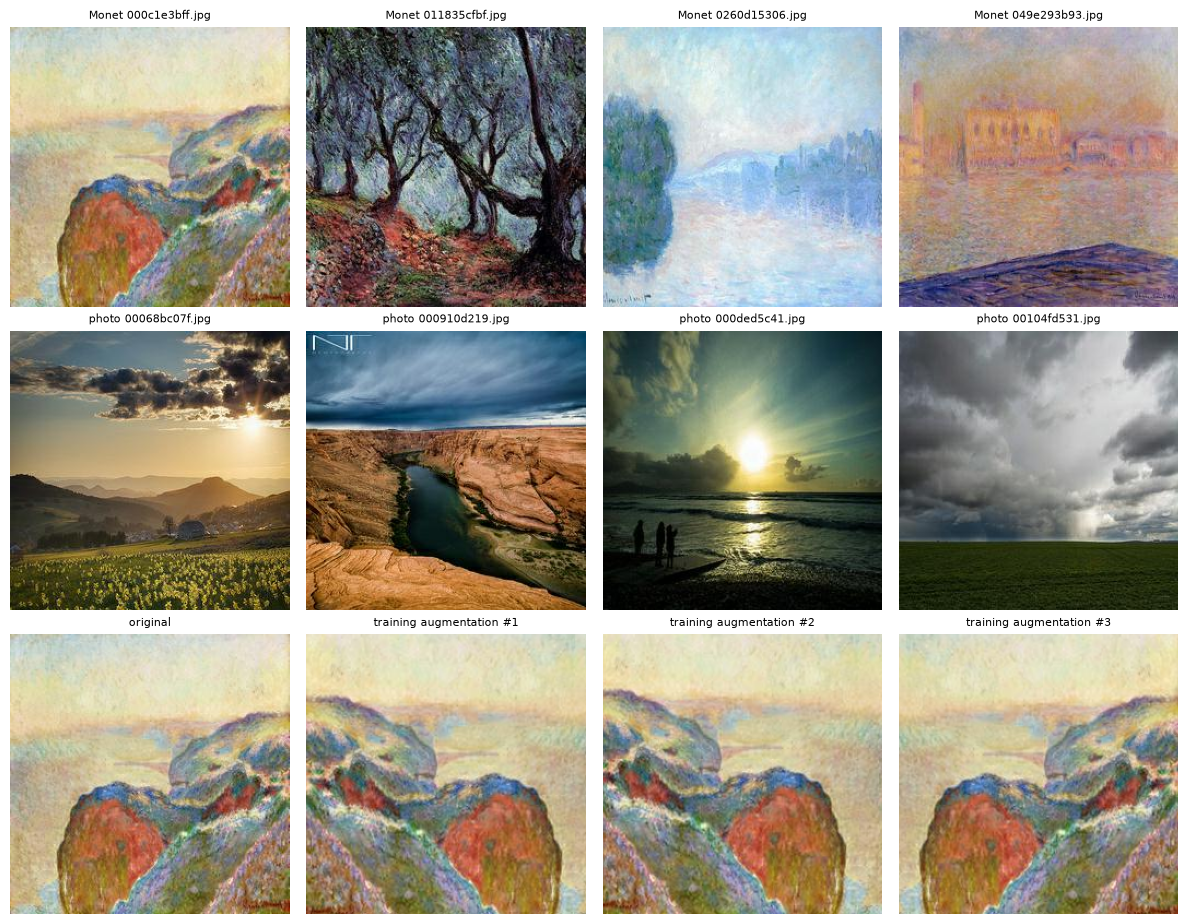

In [5]:
# The first four files of each domain in sorted order (not hand-picked), plus three training crops of one painting.
fig, axes = plt.subplots(3, 4, figsize=(12, 9.3))
for ax, p in zip(axes[0], monet_paths[:4]):
    ax.imshow(load_rgb(p)); ax.set_title(f"Monet {p.name}", fontsize=8)
for ax, p in zip(axes[1], photo_paths[:4]):
    ax.imshow(load_rgb(p)); ax.set_title(f"photo {p.name}", fontsize=8)
aug = train_transform({"load_size": 286, "image_size": 256, "hflip": True})
torch.manual_seed(SEED)
axes[2][0].imshow(load_rgb(monet_paths[0])); axes[2][0].set_title("original", fontsize=8)
for k, ax in enumerate(axes[2][1:], 1):
    ax.imshow(denormalize(aug(load_rgb(monet_paths[0]))).permute(1, 2, 0).numpy())
    ax.set_title(f"training augmentation #{k}", fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Baseline configuration (EXP-00)

| Component | Setting |
|---|---|
| Generator | ResNet-9: c7s1-64, d128, d256, 9 residual blocks, u128, u64, c7s1-3, tanh; instance norm, reflection padding; **transposed-convolution ("deconv") upsampling** |
| Discriminator | 70×70 PatchGAN: C64 (no norm), C128, C256, C512 (stride 1), 1-channel output; LeakyReLU 0.2 |
| GAN objective | LSGAN (least squares) |
| Schedule | 30 constant + 30 linear-decay epochs = 60 epochs × 1,000 steps = **60,000 steps**, batch size 1 |
| Loss weights | λ_cycle = 10, λ_identity = 5 (absolute weight on the identity L1) |
| Optimizer | Adam, β1 = 0.5, β2 = 0.999, LR 2e-4 for G and D |
| Replay pool | 50 past fakes per discriminator |
| Seed | 8503 |

The dictionary below is the configuration the notebook trains with. The next cell checks it, setting by setting, against `configs/baseline.yaml`, the file that produced EXP-00 and EXP-05. The only intentional difference is `data.num_workers`. On Windows, DataLoader workers cannot import classes defined inside a notebook, so the notebook loads data in the main process (`0`). That changes which random crop each step draws, but not the data, model or algorithm.

In [6]:
CONFIG = {
    "seed": SEED,
    "data": {"image_size": 256, "load_size": 286, "hflip": True, "steps_per_epoch": 1000,
             "num_workers": 0 if os.name == "nt" else 4},
    "model": {"ngf": 64, "ndf": 64, "n_res_blocks": 9, "n_d_layers": 3, "norm": "instance",
              "upsample": "deconv", "init_gain": 0.02},
    "loss": {"gan_mode": "lsgan", "lambda_cycle": 10.0, "lambda_identity": 5.0},
    "train": {"batch_size": 1, "lr": 0.0002, "beta1": 0.5, "beta2": 0.999,
              "n_epochs_constant": 30, "n_epochs_decay": 30, "pool_size": 50,
              "amp": "none", "allow_tf32": True, "cudnn_benchmark": True, "grad_clip_norm": None,
              "step_log_every": 10, "print_every": 100, "sample_every_epochs": 1,
              "checkpoint_every_epochs": 5, "full_checkpoint_every_epochs": 10,
              "max_consecutive_nonfinite": 20, "spike_factor": 3.0, "spike_warmup_steps": 500,
              "num_sample_images": 4},
    "inference": {"batch_size": 16, "jpg_quality": 95},
}


def flatten(d: dict, prefix: str = "") -> dict:
    out = {}
    for k, v in d.items():
        out.update(flatten(v, f"{prefix}{k}.") if isinstance(v, dict) else {f"{prefix}{k}": v})
    return out


def notebook_config_hash(cfg: dict) -> str:
    return hashlib.sha256(json.dumps(cfg, sort_keys=True, default=str).encode()).hexdigest()[:16]


with open(MEMBER / "configs" / "baseline.yaml", encoding="utf-8") as h:
    baseline_yaml = yaml.safe_load(h)
nb_flat, yaml_flat = flatten(CONFIG), flatten(baseline_yaml)
compared = {k: (v, yaml_flat.get(k, "<absent>")) for k, v in nb_flat.items() if k not in ("seed", "data.num_workers")}
mismatch = {k: v for k, v in compared.items() if v[0] != v[1]}
assert not mismatch, f"notebook CONFIG differs from configs/baseline.yaml: {mismatch}"
print(f"{len(compared)}/{len(compared)} notebook settings are identical to configs/baseline.yaml")
print(f"seed: notebook {SEED}, baseline.yaml {baseline_yaml['seed']}"
      + ("" if SEED == baseline_yaml["seed"] else "  <- NOT the official seed"))
print(f"data.num_workers: notebook {CONFIG['data']['num_workers']}, baseline.yaml {baseline_yaml['data']['num_workers']}")

36/36 notebook settings are identical to configs/baseline.yaml
seed: notebook 8503, baseline.yaml 8503
data.num_workers: notebook 0, baseline.yaml 4


## 6. Generator

The generator is the ResNet encoder–transformer–decoder of Johnson et al. (2016), used by CycleGAN for 256×256 images. Why each block exists:

| Block | Role |
|---|---|
| `ReflectionPad2d(3)` + 7×7 conv, 64 ch | Large first receptive field. Reflection padding avoids the dark border artifacts that zero padding causes. |
| Two stride-2 3×3 convs (128, 256 ch) | Downsample 256 → 64 pixels so the residual blocks work on a compact feature grid with a wide receptive field |
| 9 residual blocks (256 ch) | Each block learns a small *edit* to the features (`x + f(x)`). Style transfer keeps the scene layout and changes texture and colour, which matches residual editing. |
| Two stride-2 transposed convs (128, 64 ch) | Upsample back to 256 pixels. Uneven kernel overlap here is the known source of checkerboard texture (tested in EXP-01). |
| `ReflectionPad2d(3)` + 7×7 conv to 3 ch + `tanh` | Back to RGB, bounded to [-1, 1] like the normalized inputs |
| Instance normalization (no affine, no running stats) | Per-image statistics: one painting's contrast does not leak into another's, and train/eval behave identically at batch size 1 |

The layer layout and parameter names are identical to those of the models used for the recorded runs, which lets Section 13 load their checkpoints with `strict=True`. `resize_conv` (nearest upsample + 3×3 conv) is the EXP-01 alternative and is kept so that EXP-01's checkpoint also loads.

In [7]:
def norm_layer(kind: str, channels: int) -> nn.Module:
    if kind == "instance":
        return nn.InstanceNorm2d(channels, affine=False, track_running_stats=False)
    if kind == "batch":
        return nn.BatchNorm2d(channels)
    if kind == "none":
        return nn.Identity()
    raise ValueError(f"unknown norm: {kind}")


class ResnetBlock(nn.Module):
    """Two 3x3 convs with reflection padding and a skip connection (channels in = channels out)."""

    def __init__(self, channels: int, norm: str) -> None:
        super().__init__()
        use_bias = norm == "instance"   # instance norm has no affine shift, so the conv keeps its bias
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(channels, channels, kernel_size=3, bias=use_bias),
            norm_layer(norm, channels), nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1), nn.Conv2d(channels, channels, kernel_size=3, bias=use_bias),
            norm_layer(norm, channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.block(x)


class ResnetGenerator(nn.Module):
    """c7s1-64, d128, d256, R256 x n_blocks, u128, u64, c7s1-3, tanh  (3x256x256 in [-1, 1] -> same)."""

    def __init__(self, in_ch: int = 3, out_ch: int = 3, ngf: int = 64, n_blocks: int = 9,
                 norm: str = "instance", upsample: str = "deconv") -> None:
        super().__init__()
        use_bias = norm == "instance"
        layers = [nn.ReflectionPad2d(3), nn.Conv2d(in_ch, ngf, kernel_size=7, bias=use_bias),
                  norm_layer(norm, ngf), nn.ReLU(inplace=True)]
        ch = ngf
        for _ in range(2):                                        # downsampling: 64 -> 128 -> 256 channels
            layers += [nn.Conv2d(ch, ch * 2, kernel_size=3, stride=2, padding=1, bias=use_bias),
                       norm_layer(norm, ch * 2), nn.ReLU(inplace=True)]
            ch *= 2
        layers += [ResnetBlock(ch, norm) for _ in range(n_blocks)]  # transformation at 64x64
        for _ in range(2):                                        # upsampling: 256 -> 128 -> 64 channels
            if upsample == "deconv":
                up = [nn.ConvTranspose2d(ch, ch // 2, kernel_size=3, stride=2, padding=1, output_padding=1,
                                         bias=use_bias)]
            elif upsample == "resize_conv":
                up = [nn.Upsample(scale_factor=2, mode="nearest"), nn.ReflectionPad2d(1),
                      nn.Conv2d(ch, ch // 2, kernel_size=3, bias=use_bias)]
            else:
                raise ValueError(f"unknown upsample mode: {upsample}")
            layers += up + [norm_layer(norm, ch // 2), nn.ReLU(inplace=True)]
            ch //= 2
        layers += [nn.ReflectionPad2d(3), nn.Conv2d(ch, out_ch, kernel_size=7), nn.Tanh()]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


def count_parameters(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters())


@torch.no_grad()
def layer_table(net: nn.Module, input_shape=(1, 3, 256, 256)) -> pd.DataFrame:
    """Push a dummy tensor through net.model layer by layer; record each output shape and parameter count."""
    x, rows = torch.zeros(input_shape), []
    for i, layer in enumerate(net.model):
        x = layer(x)
        rows.append({"#": i, "layer": type(layer).__name__, "output (C, H, W)": tuple(x.shape[1:]),
                     "parameters": sum(p.numel() for p in layer.parameters())})
    return pd.DataFrame(rows).set_index("#")


G_demo = ResnetGenerator()
display(layer_table(G_demo))
print(f"generator parameters: {count_parameters(G_demo):,}")

,layer,"output (C, H, W)",parameters
#,,,
0,ReflectionPad2d,"(3, 262, 262)",0
1,Conv2d,"(64, 256, 256)",9472
2,InstanceNorm2d,"(64, 256, 256)",0
3,ReLU,"(64, 256, 256)",0
4,Conv2d,"(128, 128, 128)",73856
5,InstanceNorm2d,"(128, 128, 128)",0
6,ReLU,"(128, 128, 128)",0
7,Conv2d,"(256, 64, 64)",295168
8,InstanceNorm2d,"(256, 64, 64)",0


generator parameters: 11,378,179


In [8]:
# Forward pass of an untrained generator on a real Monet: shapes and value range only (weights are random).
x = eval_transform(256)(load_rgb(monet_paths[0])).unsqueeze(0)
with torch.no_grad():
    y = G_demo.eval()(x)
print(f"input  {tuple(x.shape)}  range [{x.min():.2f}, {x.max():.2f}]")
print(f"output {tuple(y.shape)}  range [{y.min():.2f}, {y.max():.2f}]  (tanh keeps it inside [-1, 1])")
del G_demo

input  (1, 3, 256, 256)  range [-1.00, 1.00]
output (1, 3, 256, 256)  range [-1.00, 0.95]  (tanh keeps it inside [-1, 1])


## 7. Discriminator: 70×70 PatchGAN

Instead of one real/fake score per image, the PatchGAN outputs a 30×30 map of raw scores. Each score judges one overlapping 70×70 patch of the input. Painting style is mostly local texture, so patch-level judgments give a denser training signal than a single global score, with far fewer parameters. There is no sigmoid: the LSGAN loss works on raw scores. The first layer has no normalization (paper recipe); later layers use instance normalization and LeakyReLU(0.2).

**Receptive field.** For a stack of convolutions, $r \leftarrow r + (k-1)\,j$ and $j \leftarrow j\cdot s$, starting from $r = j = 1$. Here $k$ is the kernel size, $s$ the stride and $j$ the cumulative stride. The five 4×4 convolutions (strides 2, 2, 2, 1, 1) give $r = 70$; the cell below computes it from the network itself.

In [9]:
class PatchDiscriminator(nn.Module):
    """70x70 PatchGAN: C64 (no norm), C128, C256, C512 (stride 1), then a 1-channel conv (raw scores)."""

    def __init__(self, in_ch: int = 3, ndf: int = 64, n_layers: int = 3, norm: str = "instance") -> None:
        super().__init__()
        use_bias = norm == "instance"
        layers = [nn.Conv2d(in_ch, ndf, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True)]
        mult = 1
        for n in range(1, n_layers):
            prev, mult = mult, min(2 ** n, 8)
            layers += [nn.Conv2d(ndf * prev, ndf * mult, kernel_size=4, stride=2, padding=1, bias=use_bias),
                       norm_layer(norm, ndf * mult), nn.LeakyReLU(0.2, inplace=True)]
        prev, mult = mult, min(2 ** n_layers, 8)
        layers += [nn.Conv2d(ndf * prev, ndf * mult, kernel_size=4, stride=1, padding=1, bias=use_bias),
                   norm_layer(norm, ndf * mult), nn.LeakyReLU(0.2, inplace=True),
                   nn.Conv2d(ndf * mult, 1, kernel_size=4, stride=1, padding=1)]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


def receptive_field(net: nn.Module) -> int:
    r, j = 1, 1
    for m in net.modules():
        if isinstance(m, nn.Conv2d):
            r += (m.kernel_size[0] - 1) * j
            j *= m.stride[0]
    return r


D_demo = PatchDiscriminator()
display(layer_table(D_demo))
print(f"discriminator parameters: {count_parameters(D_demo):,}")
print(f"output for a 256x256 input: {tuple(D_demo(torch.zeros(1, 3, 256, 256)).shape)}  (one score per patch)")
print(f"receptive field of each output score: {receptive_field(D_demo)} x {receptive_field(D_demo)} pixels")
del D_demo

,layer,"output (C, H, W)",parameters
#,,,
0,Conv2d,"(64, 128, 128)",3136
1,LeakyReLU,"(64, 128, 128)",0
2,Conv2d,"(128, 64, 64)",131200
3,InstanceNorm2d,"(128, 64, 64)",0
4,LeakyReLU,"(128, 64, 64)",0
5,Conv2d,"(256, 32, 32)",524544
6,InstanceNorm2d,"(256, 32, 32)",0
7,LeakyReLU,"(256, 32, 32)",0
8,Conv2d,"(512, 31, 31)",2097664


discriminator parameters: 2,764,737
output for a 256x256 input: (1, 1, 30, 30)  (one score per patch)
receptive field of each output score: 70 x 70 pixels


## 8. Loss functions

Notation: $a$ is a Monet (domain A), $b$ a photo (domain B), $G=$ `G_A2B`, $F=$ `G_B2A`. All L1 terms are means over pixels and channels.

**Adversarial (LSGAN).** Discriminators regress real patches to 1 and fake patches to 0. Generators push their fakes toward 1:

$$\mathcal{L}_{D_B} = \tfrac12\Big(\mathbb{E}_b\big[(D_B(b)-1)^2\big] + \mathbb{E}_a\big[D_B(\tilde b)^2\big]\Big),\qquad
\mathcal{L}^{A2B}_{adv} = \mathbb{E}_a\big[(D_B(G(a))-1)^2\big]$$

Here $\tilde b$ is a fake photo drawn from the replay pool. $D_A$ and $\mathcal{L}^{B2A}_{adv}$ are symmetric. Least squares keeps penalizing fakes that are on the "real" side but far from the target, which gives smoother gradients than the log loss (Mao et al., 2017). The ½ factor slows the discriminators relative to the generators, as in the paper.

**Cycle consistency.** Translating there and back must return the input:
$$\mathcal{L}_{cyc} = \mathbb{E}_a\big\|F(G(a)) - a\big\|_1 + \mathbb{E}_b\big\|G(F(b)) - b\big\|_1$$
This term is what keeps the scene content. Without it, $G$ could map every Monet to any plausible photo.

**Identity.** A generator fed an image that is already in its target domain should change nothing:
$$\mathcal{L}_{idt} = \mathbb{E}_a\big\|F(a) - a\big\|_1 + \mathbb{E}_b\big\|G(b) - b\big\|_1$$
Without it the generators may shift the colour palette (the paper shows daytime scenes turning to dusk).

**Total generator objective** (both generators are updated jointly):
$$\mathcal{L}_G = \mathcal{L}^{A2B}_{adv} + \mathcal{L}^{B2A}_{adv} + \lambda_{cyc}\,\mathcal{L}_{cyc} + \lambda_{idt}\,\mathcal{L}_{idt},\qquad \lambda_{cyc}=10,\ \lambda_{idt}=5$$

In [10]:
class GANLoss(nn.Module):
    """Adversarial loss against a constant target map: 1 for "real", 0 for "fake"."""

    def __init__(self, mode: str = "lsgan") -> None:
        super().__init__()
        assert mode in ("lsgan", "vanilla"), mode
        self.mode = mode

    def forward(self, prediction: torch.Tensor, target_is_real: bool) -> torch.Tensor:
        prediction = prediction.float()
        target = torch.ones_like(prediction) if target_is_real else torch.zeros_like(prediction)
        if self.mode == "lsgan":
            return F.mse_loss(prediction, target)
        return F.binary_cross_entropy_with_logits(prediction, target)


def l1(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return F.l1_loss(a.float(), b.float())


def generator_losses(real_A, real_B, fake_A, fake_B, rec_A, rec_B, idt_A, idt_B, pred_fake_A, pred_fake_B,
                     gan: GANLoss, lambda_cycle: float, lambda_identity: float) -> dict:
    """Every generator loss term separately, plus the weighted total."""
    zero = torch.zeros((), device=real_A.device)
    losses = {
        "adv_A2B": gan(pred_fake_B, True),     # G_A2B wants D_B to call its fake photos real
        "adv_B2A": gan(pred_fake_A, True),     # G_B2A wants D_A to call its fake Monets real
        "cycle_A": l1(rec_A, real_A),          # Monet -> photo -> Monet
        "cycle_B": l1(rec_B, real_B),          # photo -> Monet -> photo
        "idt_A": l1(idt_A, real_A) if idt_A is not None else zero,   # G_B2A(Monet) should stay the same Monet
        "idt_B": l1(idt_B, real_B) if idt_B is not None else zero,   # G_A2B(photo) should stay the same photo
    }
    losses["G_total"] = (losses["adv_A2B"] + losses["adv_B2A"]
                         + lambda_cycle * (losses["cycle_A"] + losses["cycle_B"])
                         + lambda_identity * (losses["idt_A"] + losses["idt_B"]))
    return losses


def discriminator_loss(disc: nn.Module, real: torch.Tensor, fake_from_pool: torch.Tensor, gan: GANLoss) -> dict:
    """0.5 * (loss on real + loss on a pooled fake); the fake is detached so only D receives gradients."""
    pred_real, pred_fake = disc(real), disc(fake_from_pool.detach())
    loss_real, loss_fake = gan(pred_real, True), gan(pred_fake, False)
    return {"loss": 0.5 * (loss_real + loss_fake), "loss_real": loss_real, "loss_fake": loss_fake,
            "pred_real_mean": pred_real.detach().float().mean(), "pred_fake_mean": pred_fake.detach().float().mean()}


# Sanity check: a perfect discriminator scores real = 1, fake = 0 -> zero LSGAN loss; swapped -> loss 1.
gan = GANLoss("lsgan")
ones, zeros = torch.ones(1, 1, 30, 30), torch.zeros(1, 1, 30, 30)
print("LSGAN: real scored 1 ->", gan(ones, True).item(), "| fake scored 0 ->", gan(zeros, False).item(),
      "| real scored 0 ->", gan(zeros, True).item())

LSGAN: real scored 1 -> 0.0 | fake scored 0 -> 0.0 | real scored 0 -> 1.0


## 9. CycleGAN assembly

Four networks, initialized as in the paper: conv weights ~ N(0, 0.02), biases 0. Nothing pretrained is loaded. The forward/cycle structure of one training step:

```
real_A (Monet) ──G_A2B──► fake_B ──G_B2A──► rec_A ≈ real_A      (forward cycle)
real_B (photo) ──G_B2A──► fake_A ──G_A2B──► rec_B ≈ real_B      (backward cycle)
real_A ──G_B2A──► idt_A ≈ real_A        real_B ──G_A2B──► idt_B ≈ real_B   (identity)
D_B: real_B vs fake_B (photos)          D_A: real_A vs fake_A (Monets)
```

In [11]:
def init_weights(module: nn.Module, gain: float = 0.02) -> None:
    def _init(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight, 0.0, gain)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight, 1.0, gain)
            nn.init.zeros_(m.bias)
    module.apply(_init)


def build_models(model_cfg: dict) -> dict:
    """G_A2B, G_B2A (ResNet generators) and D_A, D_B (PatchGANs), freshly initialized: training from scratch."""
    up = model_cfg.get("upsample", "deconv")
    nets = {"G_A2B": ResnetGenerator(3, 3, model_cfg["ngf"], model_cfg["n_res_blocks"], model_cfg["norm"], up),
            "G_B2A": ResnetGenerator(3, 3, model_cfg["ngf"], model_cfg["n_res_blocks"], model_cfg["norm"], up),
            "D_A": PatchDiscriminator(3, model_cfg["ndf"], model_cfg["n_d_layers"], model_cfg["norm"]),   # judges Monets
            "D_B": PatchDiscriminator(3, model_cfg["ndf"], model_cfg["n_d_layers"], model_cfg["norm"])}   # judges photos
    for net in nets.values():
        init_weights(net, model_cfg.get("init_gain", 0.02))
    return nets


set_seed(SEED)
nets = build_models(CONFIG["model"])
counts = {k: count_parameters(v) for k, v in nets.items()}
counts["total"] = sum(counts.values())
display(pd.DataFrame({"parameters": counts}).T)
assert counts["total"] == 28_285_832, counts   # same count as the recorded runs (manifest "parameters")

# One forward/cycle pass on a real (Monet, photo) pair with the untrained networks: shapes and initial losses.
tf = eval_transform(256)
real_A, real_B = tf(load_rgb(monet_paths[0])).unsqueeze(0), tf(load_rgb(photo_paths[0])).unsqueeze(0)
with torch.no_grad():
    fake_B = nets["G_A2B"](real_A); rec_A = nets["G_B2A"](fake_B)
    fake_A = nets["G_B2A"](real_B); rec_B = nets["G_A2B"](fake_A)
    idt_A, idt_B = nets["G_B2A"](real_A), nets["G_A2B"](real_B)
    pred_fake_B, pred_fake_A = nets["D_B"](fake_B), nets["D_A"](fake_A)
    losses = generator_losses(real_A, real_B, fake_A, fake_B, rec_A, rec_B, idt_A, idt_B, pred_fake_A, pred_fake_B,
                              GANLoss("lsgan"), CONFIG["loss"]["lambda_cycle"], CONFIG["loss"]["lambda_identity"])
shapes = {"real_A": real_A, "fake_B = G_A2B(real_A)": fake_B, "rec_A = G_B2A(fake_B)": rec_A,
          "real_B": real_B, "fake_A = G_B2A(real_B)": fake_A, "rec_B = G_A2B(fake_A)": rec_B,
          "D_B(fake_B)": pred_fake_B, "D_A(fake_A)": pred_fake_A}
display(pd.DataFrame({"shape": {k: tuple(v.shape) for k, v in shapes.items()}}).T)
print("losses at initialization:", {k: round(float(v), 4) for k, v in losses.items()})
del nets, fake_A, fake_B, rec_A, rec_B, idt_A, idt_B

,G_A2B,G_B2A,D_A,D_B,total
parameters,11378179,11378179,2764737,2764737,28285832


,real_A,fake_B = G_A2B(real_A),rec_A = G_B2A(fake_B),real_B,fake_A = G_B2A(real_B),rec_B = G_A2B(fake_A),D_B(fake_B),D_A(fake_A)
shape,"(1, 3, 256, 256)","(1, 3, 256, 256)","(1, 3, 256, 256)","(1, 3, 256, 256)","(1, 3, 256, 256)","(1, 3, 256, 256)","(1, 1, 30, 30)","(1, 1, 30, 30)"


losses at initialization: {'adv_A2B': 3.8519, 'adv_B2A': 4.8061, 'cycle_A': 0.687, 'cycle_B': 0.6565, 'idt_A': 0.6789, 'idt_B': 0.6506, 'G_total': 28.7399}


## 10. Optimizers and learning-rate schedule

* **Two Adam optimizers.** One updates both generators jointly, because the cycle loss couples them. The other updates both discriminators. Both use β = (0.5, 0.999), the GAN-standard lower β1 that reduces momentum oscillation.
* **Learning rate.** 2e-4 for G and D. The training script of the recorded runs also accepted an optional separate `train.lr_D`, used only by EXP-04. It defaults to `train.lr`, so every other run used 2e-4 for D.
* **Schedule** (`LambdaLR`, stepped once per epoch). The factor for epoch index $e$ (0-based) is $1 - \max(0,\ e+1-30)/31$:
  * Epochs 1–30 run at the full LR.
  * Epochs 31–60 decay linearly: epoch 31 uses 2e-4·30/31 and epoch 60 uses 2e-4/31.
  * The LR is exactly 0 after the last epoch.

{'epoch 1': '2.000e-04', 'epoch 30': '2.000e-04', 'epoch 31': '1.935e-04', 'epoch 45': '1.032e-04', 'epoch 60': '6.452e-06'} | after epoch 60: 0.0


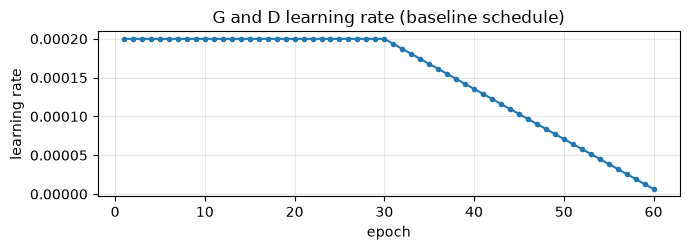

In [12]:
def make_optimizers(nets: dict, tr: dict):
    betas = (tr["beta1"], tr["beta2"])
    opt_G = torch.optim.Adam(itertools.chain(nets["G_A2B"].parameters(), nets["G_B2A"].parameters()),
                             lr=tr["lr"], betas=betas)
    opt_D = torch.optim.Adam(itertools.chain(nets["D_A"].parameters(), nets["D_B"].parameters()),
                             lr=tr.get("lr_D", tr["lr"]), betas=betas)
    return opt_G, opt_D


def linear_decay(n_const: int, n_decay: int):
    """Paper schedule: factor 1 for n_const epochs, then linear decay that reaches 0 after the last epoch."""
    return lambda epoch: 1.0 - max(0, epoch + 1 - n_const) / float(n_decay + 1)


def make_schedulers(opt_G, opt_D, tr: dict):
    rule = linear_decay(tr["n_epochs_constant"], tr["n_epochs_decay"])
    return (torch.optim.lr_scheduler.LambdaLR(opt_G, rule), torch.optim.lr_scheduler.LambdaLR(opt_D, rule))


# The LR each epoch actually uses, read from a real scheduler stepped once per epoch.
probe = nn.Parameter(torch.zeros(1))
opt = torch.optim.Adam([probe], lr=CONFIG["train"]["lr"], betas=(0.5, 0.999))
sched = torch.optim.lr_scheduler.LambdaLR(opt, linear_decay(30, 30))
lrs = []
for epoch in range(60):
    lrs.append(opt.param_groups[0]["lr"])
    opt.step(); sched.step()
print({f"epoch {e}": f"{lrs[e - 1]:.3e}" for e in (1, 30, 31, 45, 60)}, "| after epoch 60:", opt.param_groups[0]["lr"])
plt.figure(figsize=(7, 2.6))
plt.plot(range(1, 61), lrs, marker=".")
plt.xlabel("epoch"); plt.ylabel("learning rate"); plt.title("G and D learning rate (baseline schedule)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 11. Training loop

One training step (batch size 1), in the order used by every recorded run:

1. **Generator update** with both discriminators frozen:
   * translate both ways, reconstruct both cycles, compute both identity mappings;
   * score the fakes with the discriminators, compute $\mathcal{L}_G$, take one Adam step for both generators.
   * If the loss or a gradient norm is non-finite, the step is skipped and counted.
2. **Discriminator update.** Each discriminator sees a real image and a fake drawn from its **replay pool**. Once the pool holds 50 past fakes, each query returns the new fake or, with probability ½, an older one that it replaces. This shows the discriminator several generator snapshots instead of only the newest, which damps oscillation (Shrivastava et al., 2017).
3. **Monitoring.** Gradient norms, non-finite flags, loss spikes (loss > 3 × its exponential moving average after 500 warm-up steps), and discriminator saturation (LSGAN: real scored > 0.9 and fake < 0.1 in both domains).

After each epoch the code:

* steps both LR schedulers;
* writes one row of epoch metrics;
* saves a sample grid (4 fixed Monets and 4 fixed photos: real | translated | reconstructed);
* writes checkpoints:
  * `latest.pt` every epoch (full resumable state);
  * `full_epoch_XXX.pt` every 10 epochs;
  * `generators_epoch_XXX.pt` every 5 epochs;
  * `final_generators.pt` at the end.

The checkpoint formats and file names match those of the recorded runs.

The notebook implements the FP32 path used by every recorded run (`amp: none`), without autocast or gradient clipping.

In [13]:
FULL_FORMAT, GEN_FORMAT = "task3_cyclegan_full_v1", "task3_cyclegan_generators_v1"   # same as src/train.py


class ImagePool:
    """Replay buffer of past fakes for the discriminator updates."""

    def __init__(self, pool_size: int, seed: int) -> None:
        self.pool_size, self.images, self.rng = int(pool_size), [], random.Random(seed)

    def query(self, images: torch.Tensor) -> torch.Tensor:
        if self.pool_size == 0:
            return images
        out = []
        for image in images.detach():
            image = image.unsqueeze(0)
            if len(self.images) < self.pool_size:          # fill phase: store and return the new fake
                self.images.append(image.clone()); out.append(image)
            elif self.rng.random() < 0.5:                   # return an old fake, store the new one in its slot
                idx = self.rng.randrange(self.pool_size)
                old = self.images[idx].clone(); self.images[idx] = image.clone(); out.append(old)
            else:                                           # return the new fake
                out.append(image)
        return torch.cat(out, dim=0)

    def state_dict(self) -> dict:
        return {"pool_size": self.pool_size, "images": torch.cat(self.images).cpu() if self.images else None,
                "rng": self.rng.getstate()}

    def load_state_dict(self, state: dict, device) -> None:
        self.pool_size = state["pool_size"]
        self.images = [] if state["images"] is None else [t.unsqueeze(0).to(device) for t in state["images"]]
        self.rng.setstate(state["rng"])


def set_requires_grad(nets, flag: bool) -> None:
    for net in nets:
        for p in net.parameters():
            p.requires_grad_(flag)


def grad_norm(params) -> torch.Tensor:
    """Global L2 norm of the gradients (NaN/Inf propagate so they can be detected)."""
    norms = [p.grad.detach().float().pow(2).sum() for p in params if p.grad is not None]
    return torch.stack(norms).sum().sqrt() if norms else torch.zeros(())


def capture_rng_state() -> dict:
    state = {"python": random.getstate(), "numpy": np.random.get_state(), "torch_cpu": torch.get_rng_state()}
    if torch.cuda.is_available():
        state["torch_cuda"] = torch.cuda.get_rng_state_all()
    return state


def restore_rng_state(state: dict) -> None:
    random.setstate(state["python"]); np.random.set_state(state["numpy"]); torch.set_rng_state(state["torch_cpu"])
    if torch.cuda.is_available() and "torch_cuda" in state:
        torch.cuda.set_rng_state_all(state["torch_cuda"])


def atomic_save(obj, path: Path) -> None:
    """Write to a temporary file first, so an interrupted save never leaves a half-written checkpoint."""
    tmp = path.with_name(path.name + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)

In [14]:
class CycleGANTrainer:
    """All training state in one object: networks, optimizers, schedulers, replay pools, counters."""

    def __init__(self, cfg: dict, device, ckpt_dir: Path = None, samples_dir: Path = None) -> None:
        self.cfg, self.device, self.ckpt_dir, self.samples_dir = cfg, device, ckpt_dir, samples_dir
        tr, lc = cfg["train"], cfg["loss"]
        self.nets = {k: v.to(device) for k, v in build_models(cfg["model"]).items()}
        self.G_A2B, self.G_B2A, self.D_A, self.D_B = (self.nets[k] for k in ("G_A2B", "G_B2A", "D_A", "D_B"))
        self.opt_G, self.opt_D = make_optimizers(self.nets, tr)
        self.sched_G, self.sched_D = make_schedulers(self.opt_G, self.opt_D, tr)
        self.gan = GANLoss(lc["gan_mode"])
        self.lambda_cycle, self.lambda_identity = float(lc["lambda_cycle"]), float(lc["lambda_identity"])
        self.pool_A = ImagePool(tr["pool_size"], cfg["seed"] + 11)    # past fake Monets for D_A
        self.pool_B = ImagePool(tr["pool_size"], cfg["seed"] + 13)    # past fake photos for D_B
        self.epoch = self.global_step = 0
        self.epochs_total = tr["n_epochs_constant"] + tr["n_epochs_decay"]
        self.counters = {"nonfinite_steps": 0, "spike_steps": 0, "d_saturated_steps": 0, "consecutive_nonfinite": 0,
                         "ema_G": None, "ema_D": None, "train_loop_seconds": 0.0, "images_seen": 0}
        self.events = []                                              # warnings (non-finite steps, spikes)
        self.sample_A = self.sample_B = None

    # ---- one optimization step ---------------------------------------------------------------------
    def train_step(self, batch: dict) -> dict:
        real_A = batch["A"].to(self.device, non_blocking=True)   # Monet
        real_B = batch["B"].to(self.device, non_blocking=True)   # photo
        use_idt = self.lambda_identity > 0

        # 1) Generators. D is frozen so the adversarial gradient only moves G.
        set_requires_grad([self.D_A, self.D_B], False)
        self.opt_G.zero_grad(set_to_none=True)
        fake_B = self.G_A2B(real_A)                    # Monet -> photo
        rec_A = self.G_B2A(fake_B)                     # ... -> Monet (forward cycle)
        fake_A = self.G_B2A(real_B)                    # photo -> Monet
        rec_B = self.G_A2B(fake_A)                     # ... -> photo (backward cycle)
        idt_A = self.G_B2A(real_A) if use_idt else None
        idt_B = self.G_A2B(real_B) if use_idt else None
        pred_fake_B, pred_fake_A = self.D_B(fake_B), self.D_A(fake_A)
        gl = generator_losses(real_A, real_B, fake_A, fake_B, rec_A, rec_B, idt_A, idt_B, pred_fake_A, pred_fake_B,
                              self.gan, self.lambda_cycle, self.lambda_identity)
        g_ok = bool(torch.isfinite(gl["G_total"]).item())
        gn_A2B = gn_B2A = torch.full((), float("nan"))
        if g_ok:
            gl["G_total"].backward()
            gn_A2B, gn_B2A = grad_norm(self.G_A2B.parameters()), grad_norm(self.G_B2A.parameters())
            g_ok = bool(torch.isfinite(gn_A2B).item() and torch.isfinite(gn_B2A).item())
            if g_ok:
                self.opt_G.step()
            else:
                self.opt_G.zero_grad(set_to_none=True)   # skip a step with non-finite gradients

        # 2) Discriminators, each on a real image and a fake from its replay pool.
        set_requires_grad([self.D_A, self.D_B], True)
        self.opt_D.zero_grad(set_to_none=True)
        d_ok, dA, dB = False, None, None
        gn_DA = gn_DB = torch.full((), float("nan"))
        if bool(torch.isfinite(fake_A).all().item() and torch.isfinite(fake_B).all().item()):
            fake_A_pool = self.pool_A.query(fake_A.detach().float())
            fake_B_pool = self.pool_B.query(fake_B.detach().float())
            dA = discriminator_loss(self.D_A, real_A, fake_A_pool, self.gan)   # real vs fake Monet
            dB = discriminator_loss(self.D_B, real_B, fake_B_pool, self.gan)   # real vs fake photo
            d_total = dA["loss"] + dB["loss"]
            d_ok = bool(torch.isfinite(d_total).item())
            if d_ok:
                d_total.backward()
                gn_DA, gn_DB = grad_norm(self.D_A.parameters()), grad_norm(self.D_B.parameters())
                d_ok = bool(torch.isfinite(gn_DA).item() and torch.isfinite(gn_DB).item())
                if d_ok:
                    self.opt_D.step()
                else:
                    self.opt_D.zero_grad(set_to_none=True)

        nan = float("nan")
        row = {k: float(v.detach().float().item()) for k, v in gl.items()}
        for name, d in (("D_A", dA), ("D_B", dB)):
            row.update({name: d["loss"].item() if d else nan, f"{name}_real": d["loss_real"].item() if d else nan,
                        f"{name}_fake": d["loss_fake"].item() if d else nan,
                        f"{name}_pred_real": d["pred_real_mean"].item() if d else nan,
                        f"{name}_pred_fake": d["pred_fake_mean"].item() if d else nan})
        row.update({"gn_G_A2B": float(gn_A2B), "gn_G_B2A": float(gn_B2A),
                    "gn_G_total": math.sqrt(float(gn_A2B) ** 2 + float(gn_B2A) ** 2),
                    "gn_D_A": float(gn_DA), "gn_D_B": float(gn_DB),
                    "g_nonfinite": int(not g_ok), "d_nonfinite": int(not d_ok)})
        return row

    # ---- stability monitoring --------------------------------------------------------------------------
    def update_stability(self, row: dict) -> None:
        tr, c = self.cfg["train"], self.counters
        if row["g_nonfinite"] or row["d_nonfinite"]:
            c["nonfinite_steps"] += 1; c["consecutive_nonfinite"] += 1
            self.events.append(f"step {self.global_step}: non-finite value (G={row['g_nonfinite']}, D={row['d_nonfinite']})")
        else:
            c["consecutive_nonfinite"] = 0
        row["g_spike"] = row["d_spike"] = 0
        for key, value, flag in (("ema_G", row["G_total"], "g_spike"), ("ema_D", row["D_A"] + row["D_B"], "d_spike")):
            if not math.isfinite(value):
                continue
            ema = c[key]
            if ema is not None and self.global_step >= tr["spike_warmup_steps"] and value > tr["spike_factor"] * ema:
                row[flag] = 1; c["spike_steps"] += 1
                self.events.append(f"step {self.global_step}: {flag} value {value:.3f} > {tr['spike_factor']} x EMA {ema:.3f}")
            c[key] = value if ema is None else 0.99 * ema + 0.01 * value
        row["d_saturated"] = int(row["D_A_pred_real"] > 0.9 and row["D_A_pred_fake"] < 0.1
                                 and row["D_B_pred_real"] > 0.9 and row["D_B_pred_fake"] < 0.1)
        c["d_saturated_steps"] += row["d_saturated"]
        if c["consecutive_nonfinite"] >= tr["max_consecutive_nonfinite"]:
            raise FloatingPointError("too many consecutive non-finite steps; resume from the last latest.pt")

    # ---- fixed sample grid -----------------------------------------------------------------------------
    def prepare_samples(self, paths_a, paths_b) -> None:
        n, tf = int(self.cfg["train"]["num_sample_images"]), eval_transform(self.cfg["data"]["image_size"])
        self.sample_A = torch.stack([tf(load_rgb(p)) for p in deterministic_subset(paths_a, n, self.cfg["seed"] + 101)]).to(self.device)
        self.sample_B = torch.stack([tf(load_rgb(p)) for p in deterministic_subset(paths_b, n, self.cfg["seed"] + 202)]).to(self.device)

    @torch.no_grad()
    def save_samples(self, epoch: int) -> Path:
        """Rows: [real Monet | fake photo | reconstructed Monet] then [real photo | fake Monet | reconstructed photo]."""
        for g in (self.G_A2B, self.G_B2A):
            g.eval()
        fake_B = self.G_A2B(self.sample_A); rec_A = self.G_B2A(fake_B)
        fake_A = self.G_B2A(self.sample_B); rec_B = self.G_A2B(fake_A)
        for g in (self.G_A2B, self.G_B2A):
            g.train()
        tiles = [t for i in range(len(self.sample_A)) for t in (self.sample_A[i], fake_B[i], rec_A[i])]
        tiles += [t for i in range(len(self.sample_B)) for t in (self.sample_B[i], fake_A[i], rec_B[i])]
        path = self.samples_dir / f"epoch_{epoch:03d}.png"
        save_image(make_grid(denormalize(torch.stack(tiles).float().cpu()), nrow=3, padding=4, pad_value=1.0), path)
        return path

    # ---- checkpoints (same formats and file names as src/train.py) ---------------------------------------
    def full_state(self) -> dict:
        return {"format": FULL_FORMAT, "epoch": self.epoch, "global_step": self.global_step, "config": self.cfg,
                "config_hash": notebook_config_hash(self.cfg), "model_config": self.cfg["model"],
                "models": {k: v.state_dict() for k, v in self.nets.items()},
                "opt_G": self.opt_G.state_dict(), "opt_D": self.opt_D.state_dict(),
                "sched_G": self.sched_G.state_dict(), "sched_D": self.sched_D.state_dict(), "scaler": {},
                "pools": {"A": self.pool_A.state_dict(), "B": self.pool_B.state_dict()},
                "rng": capture_rng_state(), "counters": dict(self.counters)}

    def generator_state(self) -> dict:
        return {"format": GEN_FORMAT, "epoch": self.epoch, "global_step": self.global_step,
                "config_hash": notebook_config_hash(self.cfg), "model_config": self.cfg["model"],
                "data_config": self.cfg["data"], "G_A2B": self.G_A2B.state_dict(), "G_B2A": self.G_B2A.state_dict()}

    def load_full_state(self, state: dict, restore_rng: bool = True) -> None:
        if state.get("format") != FULL_FORMAT:
            raise ValueError("not a full (resumable) checkpoint")
        for k, net in self.nets.items():
            net.load_state_dict(state["models"][k], strict=True)
        self.opt_G.load_state_dict(state["opt_G"]); self.opt_D.load_state_dict(state["opt_D"])
        self.sched_G.load_state_dict(state["sched_G"]); self.sched_D.load_state_dict(state["sched_D"])
        self.pool_A.load_state_dict(state["pools"]["A"], self.device)
        self.pool_B.load_state_dict(state["pools"]["B"], self.device)
        if restore_rng:
            restore_rng_state(state["rng"])
        self.counters.update(state["counters"])
        self.epoch, self.global_step = int(state["epoch"]), int(state["global_step"])

    def save_checkpoints(self, final: bool) -> list:
        tr, saved = self.cfg["train"], []
        def save(obj, name):
            atomic_save(obj, self.ckpt_dir / name); saved.append(name)
        save(self.full_state(), "latest.pt")
        if final or self.epoch % tr["full_checkpoint_every_epochs"] == 0:
            save(self.full_state(), f"full_epoch_{self.epoch:03d}.pt")
        if final or self.epoch % tr["checkpoint_every_epochs"] == 0:
            save(self.generator_state(), f"generators_epoch_{self.epoch:03d}.pt")
        if final:
            save(self.generator_state(), "final_generators.pt")
        return saved

In [15]:
MEAN_KEYS = ["G_total", "adv_A2B", "adv_B2A", "cycle_A", "cycle_B", "idt_A", "idt_B", "D_A", "D_B",
             "D_A_pred_real", "D_A_pred_fake", "D_B_pred_real", "D_B_pred_fake"]


def append_csv(path: Path, row: dict) -> None:
    new = not path.exists()
    with open(path, "a", newline="", encoding="utf-8") as h:
        w = csv.DictWriter(h, fieldnames=list(row), extrasaction="ignore")
        if new:
            w.writeheader()
        w.writerow(row)


def train(cfg: dict, run_id: str, ckpt_dir: Path, run_dir: Path, samples_dir: Path, paths_A, paths_B, device,
          resume_from: Path = None, print_steps: bool = False) -> dict:
    """Train a CycleGAN for cfg's schedule. Writes step/epoch CSVs, a text log, samples, checkpoints, a manifest."""
    tr = cfg["train"]
    assert tr["amp"] == "none" and tr["grad_clip_norm"] is None, "the notebook implements the FP32 path of the recorded runs"
    for d in (ckpt_dir, run_dir, samples_dir):
        d.mkdir(parents=True, exist_ok=True)

    def log(msg: str, show: bool = True) -> None:
        line = f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}"
        with open(run_dir / "train_log.txt", "a", encoding="utf-8") as h:
            h.write(line + "\n")
        if show:
            print(line)

    set_seed(int(cfg["seed"]))                                       # same order as src/train.py:
    backends = configure_backends(tr["allow_tf32"], tr["cudnn_benchmark"]) if device.type == "cuda" else {"cuda": False}
    trainer = CycleGANTrainer(cfg, device, ckpt_dir, samples_dir)     # seed -> networks -> data -> samples
    dataset, loader = make_train_loader(paths_A, paths_B, cfg)
    trainer.prepare_samples(paths_A, paths_B)
    if resume_from is not None:
        trainer.load_full_state(torch.load(resume_from, map_location="cpu", weights_only=False))
        log(f"resumed from {Path(resume_from).name} at epoch {trainer.epoch}, step {trainer.global_step}")
    log(f"run {run_id}: {len(paths_A)} Monet / {len(paths_B)} photos, epochs {trainer.epoch} -> {trainer.epochs_total}, "
        f"{cfg['data']['steps_per_epoch']} steps/epoch, device {device}, backends {backends}")
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    step_rows, epoch_rows, t_start = [], [], time.perf_counter()
    while trainer.epoch < trainer.epochs_total:
        e = trainer.epoch
        dataset.set_epoch(e)                                          # new A/B permutations for this epoch
        loader.generator.manual_seed(int(cfg["seed"]) * 1000 + e)     # crop/flip stream for this epoch
        lr_now, rows, seconds = trainer.opt_G.param_groups[0]["lr"], [], 0.0
        for batch in loader:
            t0 = time.perf_counter()
            row = trainer.train_step(batch)
            if device.type == "cuda":
                torch.cuda.synchronize()
            dt = time.perf_counter() - t0
            seconds += dt
            trainer.global_step += 1
            trainer.update_stability(row)
            row.update({"epoch": e + 1, "global_step": trainer.global_step, "lr": lr_now, "step_seconds": round(dt, 5)})
            rows.append(row)
            if trainer.global_step % tr["step_log_every"] == 0 or row["g_nonfinite"] or row["d_nonfinite"]:
                append_csv(run_dir / "step_metrics.csv", row)
                step_rows.append(row)
            if trainer.global_step % tr["print_every"] == 0:
                log(f"ep {e + 1} step {trainer.global_step} | G {row['G_total']:.4f} (adv {row['adv_A2B']:.3f}/"
                    f"{row['adv_B2A']:.3f} cyc {row['cycle_A']:.3f}/{row['cycle_B']:.3f} idt {row['idt_A']:.3f}/"
                    f"{row['idt_B']:.3f}) | D_A {row['D_A']:.4f} D_B {row['D_B']:.4f} | |g| G {row['gn_G_total']:.2f} "
                    f"D_A {row['gn_D_A']:.2f} D_B {row['gn_D_B']:.2f} | {dt * 1000:.0f} ms", show=print_steps)
        images = 2 * len(rows) * tr["batch_size"]
        trainer.counters["train_loop_seconds"] += seconds
        trainer.counters["images_seen"] += images
        trainer.sched_G.step(); trainer.sched_D.step()
        trainer.epoch = e + 1
        finite = lambda k: [r[k] for r in rows if math.isfinite(r[k])]
        ep = {"epoch": trainer.epoch, "global_step": trainer.global_step, "lr": lr_now,
              **{k: float(np.mean(finite(k))) if finite(k) else float("nan") for k in MEAN_KEYS},
              **{f"{k}_{s}": (float(np.mean(finite(k))) if s == "mean" else float(np.max(finite(k)))) if finite(k) else float("nan")
                 for k in ("gn_G_total", "gn_D_A", "gn_D_B") for s in ("mean", "max")},
              "nonfinite_steps": sum(r["g_nonfinite"] or r["d_nonfinite"] for r in rows),
              "spike_steps": sum(r["g_spike"] or r["d_spike"] for r in rows),
              "d_saturated_frac": sum(r["d_saturated"] for r in rows) / max(len(rows), 1),
              "epoch_train_seconds": round(seconds, 3), "images_per_sec": round(images / seconds, 3) if seconds else float("nan"),
              "gpu_peak_allocated_mb": round(torch.cuda.max_memory_allocated() / 2**20, 1) if torch.cuda.is_available() else None}
        append_csv(run_dir / "epoch_metrics.csv", ep)
        epoch_rows.append(ep)
        log(f"epoch {trainer.epoch}/{trainer.epochs_total}: G {ep['G_total']:.4f} D_A {ep['D_A']:.4f} D_B {ep['D_B']:.4f} "
            f"cyc {ep['cycle_A']:.4f}/{ep['cycle_B']:.4f} | {ep['images_per_sec']} img/s | non-finite "
            f"{ep['nonfinite_steps']} spikes {ep['spike_steps']} | next LR {trainer.opt_G.param_groups[0]['lr']:.3g}")
        if trainer.epoch % tr["sample_every_epochs"] == 0:
            trainer.save_samples(trainer.epoch)
        saved = trainer.save_checkpoints(final=trainer.epoch >= trainer.epochs_total)
        log(f"checkpoints: {', '.join(saved)}", show=print_steps)
    c = trainer.counters
    totals = {"epochs_completed": trainer.epoch, "global_step": trainer.global_step,
              "train_loop_seconds": round(c["train_loop_seconds"], 2), "wall_seconds": round(time.perf_counter() - t_start, 2),
              "images_per_sec": round(c["images_seen"] / c["train_loop_seconds"], 3) if c["train_loop_seconds"] else None,
              "nonfinite_steps": c["nonfinite_steps"], "spike_steps": c["spike_steps"],
              "d_saturated_steps": c["d_saturated_steps"],
              "gpu_peak_allocated_mb": round(torch.cuda.max_memory_allocated() / 2**20, 1) if torch.cuda.is_available() else None}
    (run_dir / "manifest.json").write_text(json.dumps(
        {"run_id": run_id, "trained_by": "src/Task3_Parth_CycleGAN_Final.ipynb", "seed": cfg["seed"],
         "config": cfg, "notebook_config_hash": notebook_config_hash(cfg), "environment": env, "totals": totals,
         "checkpoints": sorted(p.name for p in ckpt_dir.glob("*.pt"))}, indent=2, default=str), encoding="utf-8")
    log(f"finished: {totals}")
    return {"trainer": trainer, "step_rows": step_rows, "epoch_rows": epoch_rows, "totals": totals}

**Running it.**

* `RUN_MODE = "smoke"` (default) trains on 8 Monet + 8 photos for 2 epochs × 3 steps, inside a temporary folder that is deleted at the end of the notebook. It exercises every line of the loop, sample saving and checkpointing on the real data without producing a model.
* `RUN_MODE = "full"` trains the 60-epoch baseline into `checkpoints/<run_id>/` and `outputs/{runs,samples}/<run_id>/`. It refuses to reuse an existing run folder.
* `RUN_MODE = "none"` skips training.

In [16]:
RUN_RESULT, SMOKE_TMP = None, None
if RUN_MODE == "smoke":
    SMOKE_TMP = tempfile.TemporaryDirectory(prefix="task3_notebook_smoke_")
    smoke_root = Path(SMOKE_TMP.name)
    smoke_cfg = copy.deepcopy(CONFIG)
    smoke_cfg["data"]["steps_per_epoch"] = 3
    smoke_cfg["train"].update(n_epochs_constant=1, n_epochs_decay=1, step_log_every=1, print_every=1, spike_warmup_steps=0)
    RUN_RESULT = train(smoke_cfg, "notebook_smoke", smoke_root / "checkpoints", smoke_root / "run", smoke_root / "samples",
                       monet_paths[:8], photo_paths[:8], DEVICE, print_steps=True)
    print("smoke files:", sorted(p.name for p in smoke_root.rglob("*") if p.is_file()))
elif RUN_MODE == "full":
    run_id = f"task3_parth_notebook_baseline_{time.strftime('%Y%m%d-%H%M%S')}"
    ckpt_dir = MEMBER / "checkpoints" / run_id
    if ckpt_dir.exists():
        raise SystemExit(f"{rel(ckpt_dir)} already exists; refusing to overwrite a run")
    RUN_RESULT = train(CONFIG, run_id, ckpt_dir, MEMBER / "outputs" / "runs" / run_id,
                       MEMBER / "outputs" / "samples" / run_id, monet_paths, photo_paths, DEVICE)
else:
    print("RUN_MODE = 'none': training skipped")

[2026-10-01 01:13:10] run notebook_smoke: 8 Monet / 8 photos, epochs 0 -> 2, 3 steps/epoch, device cuda, backends {'cuda': True, 'cudnn_benchmark': True, 'tf32': True}


[2026-10-01 01:13:11] ep 1 step 1 | G 25.8852 (adv 3.895/4.954 cyc 0.538/0.612 idt 0.517/0.591) | D_A 3.3248 D_B 2.6709 | |g| G 146.48 D_A 81.39 D_B 73.64 | 1429 ms
[2026-10-01 01:13:11] ep 1 step 2 | G 22.2331 (adv 3.610/3.809 cyc 0.479/0.516 idt 0.471/0.502) | D_A 9.9205 D_B 5.2964 | |g| G 165.39 D_A 192.86 D_B 116.03 | 92 ms
[2026-10-01 01:13:11] ep 1 step 3 | G 21.6773 (adv 1.812/2.383 cyc 0.638/0.546 idt 0.612/0.518) | D_A 2.6278 D_B 3.4278 | |g| G 112.65 D_A 85.53 D_B 111.39 | 72 ms
[2026-10-01 01:13:11] epoch 1/2: G 23.2652 D_A 5.2911 D_B 3.7983 cyc 0.5514/0.5579 | 3.767 img/s | non-finite 0 spikes 0 | next LR 0.0001


[2026-10-01 01:13:12] checkpoints: latest.pt
[2026-10-01 01:13:12] ep 2 step 4 | G 19.5629 (adv 2.652/2.894 cyc 0.428/0.530 idt 0.427/0.462) | D_A 2.5354 D_B 2.7767 | |g| G 158.84 D_A 65.72 D_B 123.12 | 93 ms
[2026-10-01 01:13:12] ep 2 step 5 | G 20.4792 (adv 1.762/1.615 cyc 0.578/0.561 idt 0.597/0.545) | D_A 3.8766 D_B 2.1594 | |g| G 134.81 D_A 110.45 D_B 73.72 | 80 ms


[2026-10-01 01:13:12] ep 2 step 6 | G 25.7846 (adv 2.148/1.819 cyc 0.901/0.561 idt 0.904/0.536) | D_A 1.8056 D_B 2.4958 | |g| G 149.30 D_A 65.01 D_B 92.03 | 91 ms
[2026-10-01 01:13:12] epoch 2/2: G 21.9422 D_A 2.7392 D_B 2.4773 cyc 0.6356/0.5504 | 22.76 img/s | non-finite 0 spikes 0 | next LR 0


[2026-10-01 01:13:13] checkpoints: latest.pt, full_epoch_002.pt, generators_epoch_002.pt, final_generators.pt
[2026-10-01 01:13:13] finished: {'epochs_completed': 2, 'global_step': 6, 'train_loop_seconds': 1.86, 'wall_seconds': 3.55, 'images_per_sec': 6.464, 'nonfinite_steps': 0, 'spike_steps': 0, 'd_saturated_steps': 0, 'gpu_peak_allocated_mb': 8961.5}
smoke files: ['epoch_001.png', 'epoch_002.png', 'epoch_metrics.csv', 'final_generators.pt', 'full_epoch_002.pt', 'generators_epoch_002.pt', 'latest.pt', 'manifest.json', 'step_metrics.csv', 'train_log.txt']


## 12. Training diagnostics

**(a) This notebook's run.** For the smoke run these numbers only show that every diagnostic is computed. Six steps say nothing about model quality.

In [17]:
if RUN_RESULT is not None:
    cols = ["epoch", "global_step", "lr", "G_total", "adv_A2B", "adv_B2A", "cycle_A", "cycle_B", "idt_A", "idt_B",
            "D_A", "D_B", "gn_G_total", "gn_D_A", "gn_D_B", "g_nonfinite", "d_nonfinite", "g_spike", "d_spike",
            "d_saturated", "step_seconds"]
    display(pd.DataFrame(RUN_RESULT["step_rows"])[cols].round(4).set_index("global_step"))
    display(pd.DataFrame([RUN_RESULT["totals"]]))
    print("events:", RUN_RESULT["trainer"].events or "none")
    RUN_RESULT["trainer"] = None          # release the GPU memory held by the networks and optimizers
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

,epoch,lr,G_total,adv_A2B,adv_B2A,cycle_A,cycle_B,idt_A,idt_B,D_A,D_B,gn_G_total,gn_D_A,gn_D_B,g_nonfinite,d_nonfinite,g_spike,d_spike,d_saturated,step_seconds
global_step,,,,,,,,,,,,,,,,,,,,
1,1,0.0002,25.8852,3.8948,4.9536,0.5379,0.6119,0.5170,0.5908,3.3248,2.6709,146.4841,81.3949,73.6409,0,0,0,0,0,1.4290
2,1,0.0002,22.2331,3.6100,3.8091,0.4788,0.5163,0.4706,0.5020,9.9205,5.2964,165.3919,192.8612,116.0333,0,0,0,0,0,0.0921
3,1,0.0002,21.6773,1.8118,2.3831,0.6376,0.5456,0.6116,0.5185,2.6278,3.4278,112.6525,85.5280,111.3917,0,0,0,0,0,0.0717
4,2,0.0001,19.5629,2.6523,2.8938,0.4280,0.5295,0.4266,0.4617,2.5354,2.7767,158.8359,65.7152,123.1187,0,0,0,0,0,0.0928
5,2,0.0001,20.4792,1.7615,1.6145,0.5779,0.5611,0.5971,0.5455,3.8766,2.1594,134.8059,110.4547,73.7237,0,0,0,0,0,0.0796
6,2,0.0001,25.7846,2.1484,1.8193,0.9008,0.5606,0.9044,0.5362,1.8056,2.4958,149.3004,65.0128,92.0313,0,0,0,0,0,0.0912


,epochs_completed,global_step,train_loop_seconds,wall_seconds,images_per_sec,nonfinite_steps,spike_steps,d_saturated_steps,gpu_peak_allocated_mb
0,2,6,1.86,3.55,6.464,0,0,0,8961.5


events: none


**(b) The recorded full-scale runs.** These come from the per-epoch metrics logged during EXP-05 (`outputs/runs/<run_id>/epoch_metrics.csv`) and the totals in each run's manifest. All six runs finished with zero non-finite steps. "Spikes" and "D-saturated" are counts out of 60,000 steps (75,000 for EXP-02).

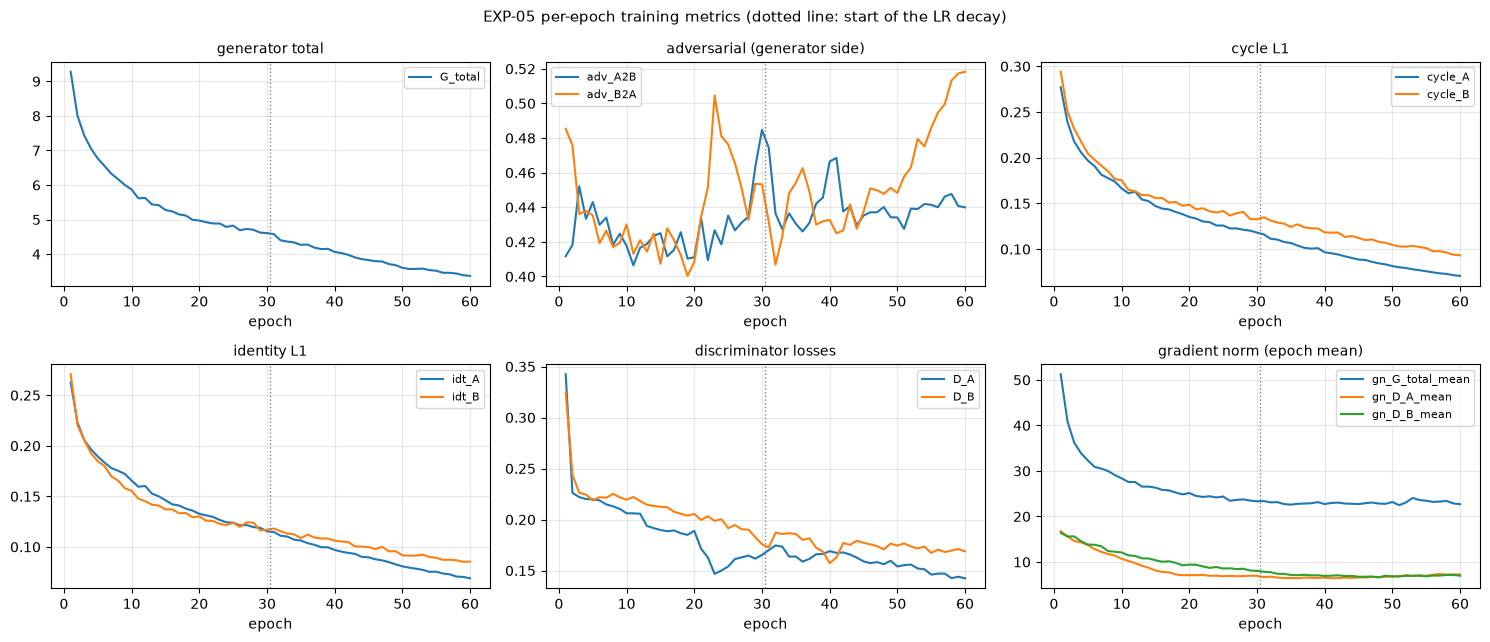

,GPU,steps,non-finite,spikes,D-saturated,images/s,train loop (min),wall (min),peak GPU allocated (MB)
run,,,,,,,,,
EXP-00,RTX 4090,60000,0,44,12,25.739,77.7,90.5,10449.4
EXP-01,RTX 5090,60000,0,189,319,24.634,81.2,97.2,17656.3
EXP-02,RTX 5090,75000,0,62,28,24.592,101.7,121.6,9027.6
EXP-03,RTX 5090,60000,0,40,29,28.170,71.0,87.8,9028.8
EXP-04,RTX 5090,60000,0,24,3,27.204,73.5,89.6,9025.1
EXP-05,RTX 5090,60000,0,38,6,28.266,70.8,87.1,9028.8


In [18]:
RUNS = {"EXP-00": "task3_parth_baseline_20260928-212005", "EXP-01": "task3_parth_exp01_resize_conv_20260929-165125",
        "EXP-02": "task3_parth_exp02_longer_decay_20260929-195357", "EXP-03": "task3_parth_exp03_identity_2p5_20260929-223904",
        "EXP-04": "task3_parth_exp04_dhalf_cycle7p5_20260930-124818",
        "EXP-05": "task3_parth_exp05_5090_baseline_control_20260930-145628"}
EXP05 = RUNS["EXP-05"]


def manifest(run_id: str) -> dict:
    return json.loads((REPO / "reproducibility" / "manifests" / f"{run_id}.json").read_text(encoding="utf-8"))


ep05 = pd.read_csv(MEMBER / "outputs" / "runs" / EXP05 / "epoch_metrics.csv")
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5))
panels = [("generator total", ["G_total"]), ("adversarial (generator side)", ["adv_A2B", "adv_B2A"]),
          ("cycle L1", ["cycle_A", "cycle_B"]), ("identity L1", ["idt_A", "idt_B"]),
          ("discriminator losses", ["D_A", "D_B"]), ("gradient norm (epoch mean)", ["gn_G_total_mean", "gn_D_A_mean", "gn_D_B_mean"])]
for ax, (title, keys) in zip(axes.ravel(), panels):
    for k in keys:
        ax.plot(ep05["epoch"], ep05[k], label=k)
    ax.axvline(30.5, color="grey", ls=":", lw=1)
    ax.set_title(title, fontsize=10); ax.set_xlabel("epoch"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("EXP-05 per-epoch training metrics (dotted line: start of the LR decay)", fontsize=11)
plt.tight_layout(); plt.show()

rows = []
for exp, run_id in RUNS.items():
    m = manifest(run_id)
    t = m["totals"]
    rows.append({"run": exp, "GPU": m["environment"]["gpu"]["name"].replace("NVIDIA GeForce ", ""),
                 "steps": t["global_step"], "non-finite": t["nonfinite_steps"], "spikes": t["spike_steps"],
                 "D-saturated": t["d_saturated_steps"], "images/s": t["images_per_sec"],
                 "train loop (min)": round(t["train_loop_seconds"] / 60, 1), "wall (min)": round(t["wall_seconds_all_sessions"] / 60, 1),
                 "peak GPU allocated (MB)": t["peak_memory"]["gpu_peak_allocated_mb"]})
display(pd.DataFrame(rows).set_index("run"))

## 13. Checkpoint loading

There are two formats, and both are loaded with `strict=True`: any missing or unexpected parameter name raises an error.

* **Generator-only** (`generators_epoch_XXX.pt`, `final_generators.pt`, ~87 MB): the weights of `G_A2B` and `G_B2A`, the model configuration, epoch, step and config hash.
* **Full** (`latest.pt`, `full_epoch_XXX.pt`, ~400 MB): additionally both discriminators, both optimizers and schedulers, both replay pools, RNG states and the monitoring counters. This is everything needed to resume training exactly where it stopped.

In [19]:
def load_generators_checkpoint(path: Path, device="cpu"):
    """G_A2B and G_B2A (eval mode) from a generator-only or a full checkpoint, loaded strictly."""
    state = torch.load(path, map_location="cpu", weights_only=False)
    fmt, mc = state.get("format"), state["model_config"]
    if fmt not in (GEN_FORMAT, FULL_FORMAT):
        raise ValueError(f"unknown checkpoint format {fmt!r}")
    gens = {}
    for name in ("G_A2B", "G_B2A"):
        g = ResnetGenerator(3, 3, mc["ngf"], mc["n_res_blocks"], mc["norm"], mc.get("upsample", "deconv"))
        g.load_state_dict(state[name] if fmt == GEN_FORMAT else state["models"][name], strict=True)
        gens[name] = g.to(device).eval()
    meta = {k: state.get(k) for k in ("format", "epoch", "global_step", "config_hash")}
    return gens, meta


def load_full_checkpoint(path: Path, device="cpu"):
    """Rebuild the complete training state (4 networks, optimizers, schedulers, pools) from a full checkpoint."""
    state = torch.load(path, map_location="cpu", weights_only=False)
    trainer = CycleGANTrainer(state["config"], device)
    trainer.load_full_state(state, restore_rng=False)    # inspecting only: leave this notebook's RNG untouched
    return trainer, {k: state.get(k) for k in ("format", "epoch", "global_step", "config_hash")}


def same_weights(a: nn.Module, b: nn.Module) -> bool:
    sa, sb = a.state_dict(), b.state_dict()
    return sa.keys() == sb.keys() and all(torch.equal(sa[k], sb[k]) for k in sa)


checks = []
if RUN_MODE == "smoke":
    sdir = Path(SMOKE_TMP.name) / "checkpoints"
    g_smoke, meta_g = load_generators_checkpoint(sdir / "final_generators.pt")
    t_smoke, meta_f = load_full_checkpoint(sdir / "latest.pt")
    checks += [("smoke final_generators.pt: strict load, epoch/step", f"{meta_g['epoch']} / {meta_g['global_step']}"),
               ("smoke latest.pt: strict load of 4 networks + optimizers + pools", f"epoch {meta_f['epoch']}, "
                f"pool sizes {len(t_smoke.pool_A.images)}/{len(t_smoke.pool_B.images)}, LR after last epoch "
                f"{t_smoke.opt_G.param_groups[0]['lr']}"),
               ("smoke: generator weights identical in both files",
                same_weights(g_smoke["G_A2B"], t_smoke.G_A2B) and same_weights(g_smoke["G_B2A"], t_smoke.G_B2A))]
    del g_smoke, t_smoke

exp05_dir = MEMBER / "checkpoints" / EXP05
recorded = pd.read_csv(MEMBER / "experiments.csv", dtype=str).set_index("exp_id")
g05, meta05 = load_generators_checkpoint(exp05_dir / "final_generators.pt")
t05, meta05f = load_full_checkpoint(exp05_dir / "full_epoch_060.pt")
checks += [("EXP-05 final_generators.pt: strict load into the notebook's ResnetGenerator", True),
           ("EXP-05 final_generators.pt: epoch / step", f"{meta05['epoch']} / {meta05['global_step']}"),
           ("EXP-05 final_generators.pt: config hash == experiments.csv",
            f"{meta05['config_hash']} == {recorded.loc['EXP-05', 'config_hash']}: {meta05['config_hash'] == recorded.loc['EXP-05', 'config_hash']}"),
           ("EXP-05 final_generators.pt: SHA-256 (first 16)", sha256_file(exp05_dir / "final_generators.pt")[:16]),
           ("EXP-05 full_epoch_060.pt: strict load of G_A2B, G_B2A, D_A, D_B + optimizers + pools",
            f"epoch {meta05f['epoch']}, step {meta05f['global_step']}, pools {len(t05.pool_A.images)}/{len(t05.pool_B.images)}"),
           ("EXP-05 full_epoch_060.pt: initial LR G / D, LR after the last epoch",
            f"{t05.opt_G.param_groups[0]['initial_lr']} / {t05.opt_D.param_groups[0]['initial_lr']}, {t05.opt_G.param_groups[0]['lr']}"),
           ("EXP-05: final_generators == full_epoch_060 generator weights",
            same_weights(g05["G_A2B"], t05.G_A2B) and same_weights(g05["G_B2A"], t05.G_B2A))]
display(pd.DataFrame(checks, columns=["check", "result"]).set_index("check"))
del t05

,result
check,
"smoke final_generators.pt: strict load, epoch/step",2 / 6
smoke latest.pt: strict load of 4 networks + optimizers + pools,"epoch 2, pool sizes 6/6, LR after last epoch 0.0"
smoke: generator weights identical in both files,True
EXP-05 final_generators.pt: strict load into the notebook's ResnetGenerator,True
EXP-05 final_generators.pt: epoch / step,60 / 60000
EXP-05 final_generators.pt: config hash == experiments.csv,dcfb462b504c1704 == dcfb462b504c1704: True
EXP-05 final_generators.pt: SHA-256 (first 16),e979e90002d17e9c
"EXP-05 full_epoch_060.pt: strict load of G_A2B, G_B2A, D_A, D_B + optimizers + pools","epoch 60, step 60000, pools 50/50"
"EXP-05 full_epoch_060.pt: initial LR G / D, LR after the last epoch","0.0002 / 0.0002, 0.0"


## 14. Inference

Each prediction is one forward pass of the trained generator:

* **Preprocessing:** deterministic, bicubic resize and centre crop to 256, scaled to [-1, 1].
* **Conversion:** back to [0, 1], rounded to 8-bit, saved as a quality-95 JPEG named after its input file.

There is no post-processing, filtering or selection. cuDNN is switched to deterministic kernels so that predictions can be regenerated exactly.

**Check.** The cell regenerates EXP-05's first 16 Monet→photo and first 16 photo→Monet predictions, by sorted file name, into a temporary folder. It then compares them byte for byte with the prediction folders that were scored by the evaluators (`outputs/pred_*/<EXP-05 run>/final_generators_exp05/`). Identical bytes mean that this notebook's generator, preprocessing and saving match the code behind the reported results.

In [20]:
def set_inference_determinism() -> None:
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


@torch.no_grad()
def translate(generator: nn.Module, paths, out_dir: Path, device, batch_size: int = 16, quality: int = 95) -> int:
    """Translate images to out_dir/<input stem>.jpg: one generator forward pass each, no post-processing."""
    out_dir.mkdir(parents=True, exist_ok=True)
    tf, n = eval_transform(256), 0
    for start in range(0, len(paths), batch_size):
        chunk = paths[start:start + batch_size]
        y = generator(torch.stack([tf(load_rgb(p)) for p in chunk]).to(device))
        for p, img in zip(chunk, y):
            arr = denormalize(img.float()).mul(255).round().to(torch.uint8).permute(1, 2, 0).cpu().numpy()
            Image.fromarray(arr).save(out_dir / f"{p.stem}.jpg", format="JPEG", quality=quality)
            n += 1
    return n


set_inference_determinism()
gens05 = {k: g.to(DEVICE) for k, g in g05.items()}
rows = []
with tempfile.TemporaryDirectory(prefix="task3_notebook_inference_") as tmp:
    for direction, net, sources in (("A2B (Monet -> photo)", "G_A2B", monet_paths[:16]),
                                    ("B2A (photo -> Monet)", "G_B2A", photo_paths[:16])):
        out = Path(tmp) / net
        translate(gens05[net], sources, out, DEVICE, CONFIG["inference"]["batch_size"], CONFIG["inference"]["jpg_quality"])
        ref = MEMBER / "outputs" / f"pred_{direction[:3]}" / EXP05 / "final_generators_exp05"
        same = [(out / f"{p.stem}.jpg").read_bytes() == (ref / f"{p.stem}.jpg").read_bytes() for p in sources]
        mad = max(float(np.abs(np.asarray(Image.open(out / f"{p.stem}.jpg"), dtype=np.float32)
                               - np.asarray(Image.open(ref / f"{p.stem}.jpg"), dtype=np.float32)).mean()) for p in sources)
        rows.append({"direction": direction, "images": len(sources), "byte-identical to evaluated predictions": f"{sum(same)}/{len(same)}",
                     "max mean |pixel difference|": mad, "reference folder": rel(ref)})
display(pd.DataFrame(rows).set_index("direction"))
del gens05, g05
if torch.cuda.is_available():
    torch.cuda.empty_cache()

,images,byte-identical to evaluated predictions,max mean |pixel difference|,reference folder
direction,,,,
A2B (Monet -> photo),16,16/16,0.0,task3_gan/parth/outputs/pred_A2B/task3_parth_e...
B2A (photo -> Monet),16,16/16,0.0,task3_gan/parth/outputs/pred_B2A/task3_parth_e...


## 15. Evaluation

The EXP-05 results were produced by two external evaluators. This notebook does not implement any metric: it loads and displays their saved results.

| | Course evaluator (instructor, authoritative for the course) | Local evaluator |
|---|---|---|
| Code | Instructor evaluation notebook; the executed copy is `evaluation/executed/course_evaluation_exp05_executed.ipynb` | Separate local evaluation code, external to this notebook |
| Images | first 300 sorted files per folder, batch 32 | all images: 300 Monet, 7,038 photos |
| Features | torchvision Inception-v3 (ImageNet), resize/centre-crop 299 | internal: pytorch-fid FID-Inception; official-reference: torchvision Inception-v3, [-1, 1] input (matches `real_stats.npz`) |
| Metrics | FID per direction; course "MiFID" = mean cosine distance between real *i* and generated *i* (paired by sorted index) | FID, KID, precision/recall, density/coverage, cycle L1, LPIPS, content cosine, copy checks |
| Saved results | `ID,FID,MiFID` CSV (`submission_exp05.csv` for EXP-05); the combined score is **(FID + MiFID) / 2** | `outputs/eval/<run_id>/<tag>/metrics.json` and `full_metrics_report.csv` |

The two sets of numbers are on different scales and must not be compared with each other. Neither is the Kaggle leaderboard score, and no Kaggle score is claimed here.

The cell below reads the recorded EXP-05 results: `metrics.json` from the local evaluator and the numbers the instructor evaluator printed in its executed notebook.

In [21]:
m05 = json.loads((MEMBER / "outputs" / "eval" / EXP05 / "final_generators_exp05" / "metrics.json").read_text(encoding="utf-8"))
internal = []
for d, label in (("A2B", "A2B: Monet -> photo"), ("B2A", "B2A: photo -> Monet")):
    x = m05["directions"][d]
    internal.append({"direction": label, "FID (internal)": x["fid"], "KID mean": x["kid_mean"], "KID std": x["kid_std"],
                     "precision": x["precision"], "recall": x["recall"], "density": x["density"], "coverage": x["coverage"],
                     "cycle L1": x["cycle_l1"], "LPIPS input->output": x["lpips_input_vs_output"],
                     "LPIPS input->reconstruction": x["lpips_input_vs_reconstruction"], "content cosine": x["content_cosine_mean"]})
display(pd.DataFrame(internal).set_index("direction").round(4).T)
print(f"official-reference check vs real_stats.npz: {m05['reference_check']['status']}; "
      f"B2A FID vs real_stats (local approximation): {m05['directions']['B2A']['fid_vs_official_real_stats']:.4f}")


def course_values(executed_notebook: Path) -> dict:
    """Read the numbers the instructor evaluator printed (no metric is recomputed here)."""
    nb = json.loads(Path(executed_notebook).read_text(encoding="utf-8"))
    out = "".join("".join(o.get("text", "")) for c in nb["cells"] if c["cell_type"] == "code"
                  for o in c.get("outputs", []) if o.get("output_type") == "stream")
    m = re.search(r"fid_B2A=(\S+) mifid_B2A=(\S+) fid_A2B=(\S+) mifid_A2B=(\S+)", out)
    s = re.search(r"sub_fid=(\S+) sub_mifid=(\S+)", out)
    v = {"FID_A2B": float(m.group(3)), "FID_B2A": float(m.group(1)), "MiFID_A2B": float(m.group(4)),
         "MiFID_B2A": float(m.group(2)), "submission FID": float(s.group(1)), "submission MiFID": float(s.group(2))}
    v["combined"] = (v["submission FID"] + v["submission MiFID"]) / 2
    return v


c05 = course_values(MEMBER / "evaluation" / "executed" / "course_evaluation_exp05_executed.ipynb")
sub05 = pd.read_csv(MEMBER / "submission_exp05.csv", float_precision="round_trip").iloc[0]
assert sub05["FID"] == c05["submission FID"] and sub05["MiFID"] == c05["submission MiFID"]   # CSV == notebook output
display(pd.DataFrame([c05], index=["EXP-05 (course evaluator)"]))

audits = [p for p in (MEMBER / "outputs" / "human_audit").iterdir() if p.is_dir()]
print("human audit:", "no completed audit (outputs/human_audit/ holds only the placeholder); results PENDING"
      if not audits else [p.name for p in audits])

direction,A2B: Monet -> photo,B2A: photo -> Monet
FID (internal),81.0700,85.0933
KID mean,0.0176,0.0126
KID std,0.0008,0.0009
precision,0.5433,0.3605
recall,0.3558,0.5367
density,0.5778,0.3268
coverage,0.0604,0.9467
cycle L1,0.0807,0.1018
LPIPS input->output,0.2987,0.3801
LPIPS input->reconstruction,0.2669,0.2307


official-reference check vs real_stats.npz: MEASURED; B2A FID vs real_stats (local approximation): 83.7819


,FID_A2B,FID_B2A,MiFID_A2B,MiFID_B2A,submission FID,submission MiFID,combined
EXP-05 (course evaluator),103.092563,103.020159,0.42286,0.414489,103.056361,0.418674,51.737518


human audit: no completed audit (outputs/human_audit/ holds only the placeholder); results PENDING


**Copy / memorization checks for EXP-05** (recorded in `exp05_control/watcher_state.json` and the EXP-05 checkpoint-sweep report):

* No output is a byte copy of any real image.
* No output is a near-copy of its source (64×64 mean absolute difference FAIL < 2, WARN < 5). The one exception is a single WARN: one photo→Monet output out of 7,038, at MAD 4.88. It is not among the 300 images the course evaluator reads.
* No output is a near-copy of any real image of the target domain (nearest-neighbour MAD ≥ 16.7).
* No output is near-blank.

## 16. Historical experiments

Six full-scale runs. EXP-00 was trained on an RTX 4090 / CUDA 12.8 machine; EXP-01 to EXP-05 on an RTX 5090 / CUDA 13.0 machine. Every run used seed 8503 and the full dataset, and was trained from scratch. The table reads `experiments.csv`, each run's manifest and its resolved config. Historical values are displayed, never rewritten.

In [22]:
CHANGE = {"EXP-00": "none (paper recipe)", "EXP-01": "resize-conv upsampling instead of transposed conv",
          "EXP-02": "longer LR decay: 30 + 45 epochs", "EXP-03": "lambda_identity 5 -> 2.5",
          "EXP-04": "lambda_cycle 10 -> 7.5 and D LR 2e-4 -> 1e-4", "EXP-05": "none: exact replicate of baseline.yaml"}
CONCLUSION = {"EXP-00": "reference result",
              "EXP-01": "negative: less checkerboard, but discriminators dominated and fidelity dropped",
              "EXP-02": "no improvement (within run-to-run variation)",
              "EXP-03": "no improvement (within run-to-run variation)",
              "EXP-04": "no improvement; mini-search gain did not transfer",
              "EXP-05": "best local score; measures run-to-run / environment variation, not a method change"}
exps = pd.read_csv(MEMBER / "experiments.csv", dtype=str).set_index("exp_id")
base = float(exps.loc["EXP-00", "course_combined"])
rows = []
for exp, run_id in RUNS.items():
    man = manifest(run_id)
    cfg_r = yaml.safe_load((REPO / man["config_resolved"]).read_text(encoding="utf-8"))
    comb = float(exps.loc[exp, "course_combined"])
    rows.append({"run": exp, "change": CHANGE[exp], "upsampling": cfg_r["model"]["upsample"],
                 "epochs": man["totals"]["epochs_completed"], "seed": man["seed"],
                 "GPU / CUDA": f"{man['environment']['gpu']['name'].replace('NVIDIA GeForce ', '')} / {man['environment']['torch_cuda_build']}",
                 "course combined": round(comb, 4), "vs EXP-00": f"{comb - base:+.4f} ({100 * (comb - base) / base:+.2f}%)",
                 "conclusion": CONCLUSION[exp]})
display(pd.DataFrame(rows).set_index("run"))

,change,upsampling,epochs,seed,GPU / CUDA,course combined,vs EXP-00,conclusion
run,,,,,,,,
EXP-00,none (paper recipe),deconv,60,8503,RTX 4090 / 12.8,52.5733,+0.0000 (+0.00%),reference result
EXP-01,resize-conv upsampling instead of transposed conv,resize_conv,60,8503,RTX 5090 / 13.0,57.2902,+4.7169 (+8.97%),"negative: less checkerboard, but discriminator..."
EXP-02,longer LR decay: 30 + 45 epochs,deconv,75,8503,RTX 5090 / 13.0,53.2846,+0.7113 (+1.35%),no improvement (within run-to-run variation)
EXP-03,lambda_identity 5 -> 2.5,deconv,60,8503,RTX 5090 / 13.0,52.9316,+0.3583 (+0.68%),no improvement (within run-to-run variation)
EXP-04,lambda_cycle 10 -> 7.5 and D LR 2e-4 -> 1e-4,deconv,60,8503,RTX 5090 / 13.0,53.4947,+0.9215 (+1.75%),no improvement; mini-search gain did not transfer
EXP-05,none: exact replicate of baseline.yaml,deconv,60,8503,RTX 5090 / 13.0,51.7375,-0.8357 (-1.59%),best local score; measures run-to-run / enviro...


## 17. Current best result: EXP-05, combined 51.7375179073123

EXP-05 has the lowest course score so far:

* combined **51.7375**, against 52.5733 for EXP-00 (−0.84, −1.59%);
* course FID A2B 103.09 and B2A 103.02;
* course MiFID 0.4229 and 0.4145.

**EXP-05 is not an architectural or hyperparameter improvement.** It is an *exact replicate* of the baseline configuration: same resolved config (only the run name differs), same seed 8503, same data and code path, trained from scratch. It was run on different hardware and software: RTX 5090 / CUDA 13.0 instead of the RTX 4090 / CUDA 12.8 used for EXP-00. Its score differs from EXP-00 because GAN training on GPUs is not bit-reproducible (non-deterministic kernels, different GPUs and CUDA/cuDNN builds). One replicate cannot separate these sources, and the difference is **not** attributed to hardware alone. What it shows is that run-to-run / environment variation is at least ~0.8 combined points. That is as large as most of the configuration effects tested.

The checkpoint sweep below shows the same instructor evaluator on every saved generator snapshot. Epoch 60 (`final_generators.pt`) is EXP-05's best checkpoint. Epoch 55 is 0.0155 worse, which is inside the adjacent-checkpoint noise. The epoch-60 control reproduced the recorded score exactly. All checkpoints are scored on the same 300 + 300 images, so picking the minimum is optimistically biased (here it selects the final checkpoint anyway).

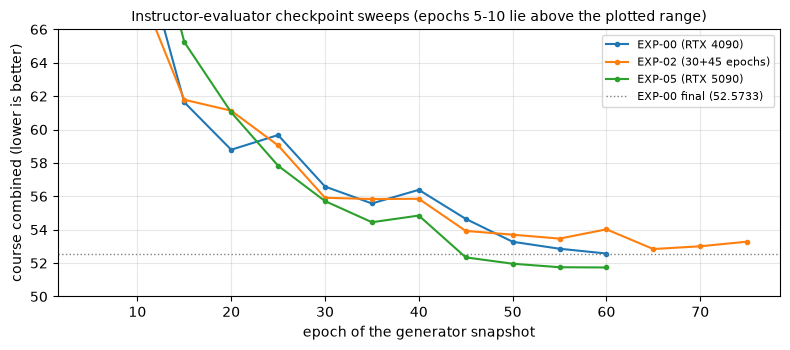

,checkpoint,FID_A2B,FID_B2A,MiFID_A2B,MiFID_B2A,combined_score,delta_vs_epoch60
epoch,,,,,,,
60,final_generators.pt,103.0926,103.0202,0.4229,0.4145,51.7375,0.0000
60,generators_epoch_060.pt,103.0926,103.0202,0.4229,0.4145,51.7375,0.0000
55,generators_epoch_055.pt,102.8009,103.3744,0.4216,0.4151,51.7530,0.0155
50,generators_epoch_050.pt,102.5950,104.4192,0.4243,0.4165,51.9637,0.2262
45,generators_epoch_045.pt,105.4018,103.1298,0.4278,0.4127,52.3430,0.6055
35,generators_epoch_035.pt,109.6135,107.3388,0.4280,0.4117,54.4480,2.7105


In [23]:
sweeps = {"EXP-00 (RTX 4090)": "checkpoint_sweep_baseline.csv", "EXP-02 (30+45 epochs)": "checkpoint_sweep_exp02.csv",
          "EXP-05 (RTX 5090)": "checkpoint_sweep_exp05.csv"}
plt.figure(figsize=(8, 3.6))
for label, name in sweeps.items():
    s = pd.read_csv(MEMBER / name, float_precision="round_trip")
    s = s[s["checkpoint"] != "final_generators.pt"].sort_values("epoch")   # final == last epoch snapshot
    plt.plot(s["epoch"], s["combined_score"], marker="o", ms=3, label=label)
plt.axhline(base, color="grey", ls=":", lw=1, label="EXP-00 final (52.5733)")
plt.ylim(50, 66); plt.xlabel("epoch of the generator snapshot"); plt.ylabel("course combined (lower is better)")
plt.title("Instructor-evaluator checkpoint sweeps (epochs 5-10 lie above the plotted range)", fontsize=10)
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

s05 = pd.read_csv(MEMBER / "checkpoint_sweep_exp05.csv", float_precision="round_trip")
display(s05[["epoch", "checkpoint", "FID_A2B", "FID_B2A", "MiFID_A2B", "MiFID_B2A", "combined_score", "delta_vs_epoch60"]]
        .head(6).round(4).set_index("epoch"))

## 18. Failure analysis

F-numbers refer to the entries in `failure_analysis.md`. Every experiment is a single seed per arm, so given the variation measured in EXP-05 only large effects can be attributed to a change.

**Checkerboard texture (EXP-00) and the resize-conv experiment (EXP-01)** (`failure_analysis.md` F1, F2).

* *Problem.* The baseline shows a periodic grid texture in flat regions (skies, water). The mean power spectrum of its B2A outputs has a period-2 peak 15.4 dB above the local background; real Monet paintings show 4.9 dB.
* *What EXP-01 changed.* Nearest-upsample + 3×3 conv in place of the transposed convolutions. The peak fell to 7.0 dB.
* *Result: worse.* From epoch 31 on the discriminators dominated: 319 D-saturated steps against 12 for the baseline, and 189 loss spikes against 44. Cycle L1 rose 33–40%, and the course combined score was 57.29 (+9.0%).

The hypothesis about the *cause* of the texture was supported, but the fix made the model worse overall. Evidence: `failure_analysis.md` (F1, F2), `experiments.csv`, EXP-01 manifest and `epoch_metrics.csv`.

**Longer decay (EXP-02, 30 + 45 epochs)** (F3). Combined 53.28 (+1.35% vs EXP-00). Its own checkpoint sweep peaked at epoch 65 (52.84), still above EXP-00. Internal B2A FID improved (87.95 vs 89.41) while the course FIDs got slightly worse. These are mixed signals within run-to-run variation. Evidence: `checkpoint_sweep_exp02.csv`.

**Identity weight 2.5 (EXP-03)** (F4). Combined 52.93 (+0.68%). No improvement.

**Cycle weight 7.5 + discriminator LR 1e-4 (EXP-04)** (F5).

* Combined 53.49 (+1.75%). Worse in both course directions and on internal FID.
* It was the most stable run (24 spikes, 3 D-saturated steps) and had a lower checkerboard peak (8.9 dB). Stability did not translate into a better score.

**Run-to-run / environment variation (EXP-00 vs EXP-05)** (F6). The same configuration and seed gave 52.57 and 51.74, a spread of 0.84 combined points. Adjacent 5-epoch checkpoints of one run differ by 0.2–1.2 points. The single-seed differences of EXP-02, EXP-03 and EXP-04 from EXP-00 (+0.36 to +0.92) are all within this range. Against the same-hardware control EXP-05, all three are worse by 2.3–3.4%. Neither comparison supports any of these changes as an improvement.

**The mini-search did not transfer** (F7). The mini benchmark trained on 100 Monet / 800 photos for 3,000 steps (10 epochs of 300) and evaluated on 300 + 300 images with the course evaluator.

* 12 of its 15 completed variants beat the mini baseline by 7–17%, including opposite changes: λ_cycle 5 (−8.5%) *and* 12.5 (−7.5%).
* The mini benchmark therefore mostly rewarded faster early progress, not better final quality.
* Its two configurations that were tested at full scale both failed (table below).
* Evidence: `mini_search/mini_experiments.csv`, `mini_search/MINI_SEARCH_FINAL_REPORT.md`.

In [24]:
mini = pd.read_csv(MEMBER / "mini_search" / "mini_experiments.csv", dtype=str).set_index("trial_id")
show = ["T001", "T017", "T002", "T005", "T006", "T007", "T009", "T015", "T018"]
display(mini.loc[show, ["key", "seed", "mini_combined", "percent_vs_mini_baseline", "decision"]]
        .assign(mini_combined=lambda d: d["mini_combined"].astype(float).round(2),
                percent_vs_mini_baseline=lambda d: pd.to_numeric(d["percent_vs_mini_baseline"], errors="coerce").round(2)))
full = {"lambda_identity 2.5 (mini T002)": ("T002", "EXP-03"), "D LR 1e-4 + lambda_cycle 7.5 (mini T015, T018)": ("T015", "EXP-04")}
display(pd.DataFrame([{"configuration": k, "mini-search change": f"{float(mini.loc[t, 'percent_vs_mini_baseline']):+.2f}%",
                       "full-scale run": e, "full-scale change vs EXP-00":
                       f"{100 * (float(exps.loc[e, 'course_combined']) - base) / base:+.2f}%"} for k, (t, e) in full.items()])
        .set_index("configuration"))

,key,seed,mini_combined,percent_vs_mini_baseline,decision
trial_id,,,,,
T001,BASE|b3000|s8503,8503,99.57,NaN,BASELINE
T017,BASE|b3000|s1337,1337,98.82,NaN,BASELINE
T002,I2.5|b3000|s8503,8503,89.06,-10.55,PROMOTE
T005,C7.5|b3000|s8503,8503,85.88,-13.75,PROMOTE
T006,C5|b3000|s8503,8503,91.07,-8.54,PROMOTE
T007,C12.5|b3000|s8503,8503,92.10,-7.51,PROMOTE
T009,D0.5|b3000|s8503,8503,83.90,-15.74,PROMOTE
T015,D0.5+C7.5|b3000|s8503,8503,82.26,-17.39,PROMOTE
T018,D0.5+C7.5|b3000|s1337,1337,82.10,-16.92,PROMOTE


,mini-search change,full-scale run,full-scale change vs EXP-00
configuration,,,
lambda_identity 2.5 (mini T002),-10.55%,EXP-03,+0.68%
"D LR 1e-4 + lambda_cycle 7.5 (mini T015, T018)",-17.39%,EXP-04,+1.75%


## 19. Visual results

Images are shown for qualitative analysis only and were not selected after the fact:

* the training sample grid uses the 4 + 4 images chosen by seed before training started;
* the prediction panels show the first six inputs by sorted file name.

Nothing shown here influenced any evaluation.

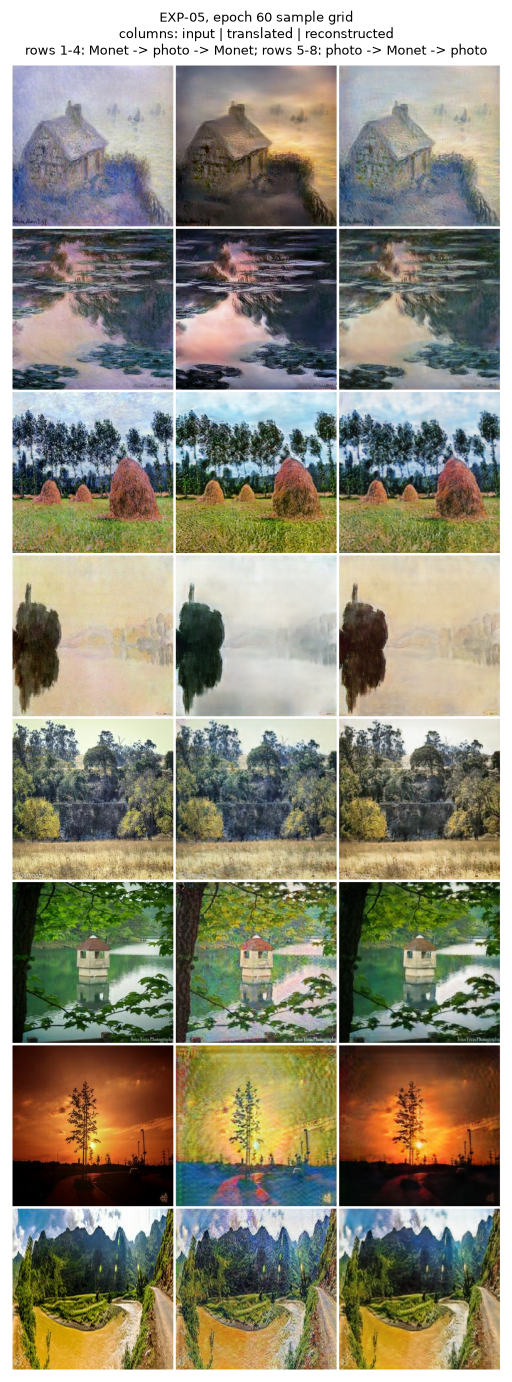

In [25]:
grid = Image.open(MEMBER / "outputs" / "samples" / EXP05 / "epoch_060.png")
plt.figure(figsize=(6.5, 17))
plt.imshow(grid); plt.axis("off")
plt.title("EXP-05, epoch 60 sample grid\ncolumns: input | translated | reconstructed\n"
          "rows 1-4: Monet -> photo -> Monet; rows 5-8: photo -> Monet -> photo", fontsize=9)
plt.show()

**What the grid shows.**

* **Photo → Monet (rows 5–8)** keeps the scene layout while shifting the palette and adding brush-like texture.
* **The sunset photo (row 7) is a failure case.** Its palette inverts to yellow/blue, and a periodic grid texture covers the sky. This is the checkerboard artifact analysed in Section 18; it is still present in EXP-05.
* **Monet → photo (rows 1–4)** mostly changes colour and contrast. Painterly texture remains, so these outputs look only partly photographic.
* **Reconstructions** (third column) are close to the inputs in every row, which is the visual counterpart of the low cycle L1 in Section 15.

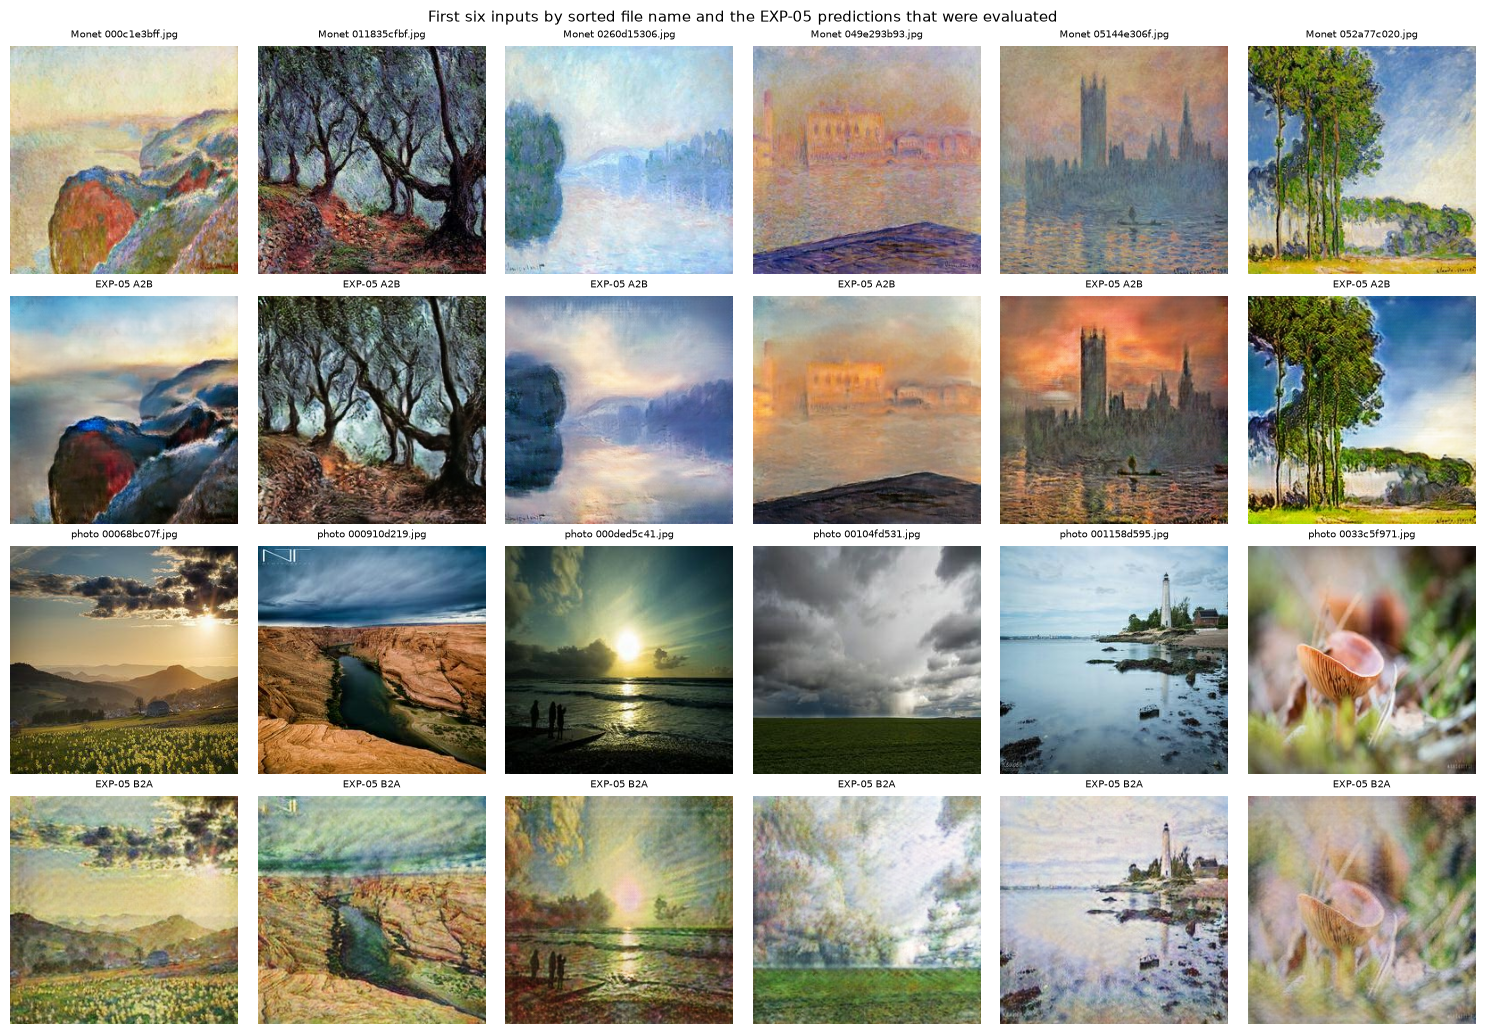

In [26]:
fig, axes = plt.subplots(4, 6, figsize=(15, 10.5))
for row, (direction, sources) in enumerate((("A2B", monet_paths[:6]), ("B2A", photo_paths[:6]))):
    pred_dir = MEMBER / "outputs" / f"pred_{direction}" / EXP05 / "final_generators_exp05"
    for col, p in enumerate(sources):
        axes[2 * row][col].imshow(load_rgb(p))
        axes[2 * row][col].set_title(("Monet " if direction == "A2B" else "photo ") + p.name, fontsize=7)
        axes[2 * row + 1][col].imshow(Image.open(pred_dir / f"{p.stem}.jpg"))
        axes[2 * row + 1][col].set_title(f"EXP-05 {direction}", fontsize=7)
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("First six inputs by sorted file name and the EXP-05 predictions that were evaluated", fontsize=11)
plt.tight_layout(); plt.show()

## 20. Reproducibility

Commands are PowerShell from the repository root; on Linux or macOS use `python` and forward slashes.

1. **Environment.** Create a Python 3.12 virtual environment (`python -m venv .venv`) and install PyTorch with CUDA:
   * RTX 5090: `.\.venv\Scripts\python.exe -m pip install torch==2.11.0 torchvision==0.26.0 --index-url https://download.pytorch.org/whl/cu130`
   * RTX 4090 / CUDA 12.8: use `cu128`.

   The exact package versions of the EXP-05 run are in `reproducibility/manifests/<run_id>_pip_freeze.txt`.
2. **Dataset.** Place the competition files in `task3_gan/data/monet_jpg/` (300 JPEGs) and `task3_gan/data/photo_jpg/` (7,038 JPEGs). Section 4 checks the counts.
3. **Seed.** `SEED` in Section 3, or `TASK3_SEED`. The official runs use 8503.
4. **Model.** Sections 6 to 10 (`build_models(CONFIG["model"])`). The configuration is checked against `configs/baseline.yaml` in Section 5.
5. **Training.** Set `RUN_MODE = "full"` and run all cells, which takes about 70 to 90 minutes on an RTX 5090 or RTX 4090. The recorded runs used the standalone script `src/train.py` with the same configuration. A new run will not reproduce their scores exactly (Section 17).
6. **Checkpoints.** `load_generators_checkpoint(...)` and `load_full_checkpoint(...)` (Section 13).
7. **Predictions.** `translate(...)` (Section 14).
8. **Evaluation.** The course evaluator and the local evaluator are external to this notebook. The saved EXP-05 results are in `evaluation/executed/course_evaluation_exp05_executed.ipynb`, `outputs/eval/<run_id>/final_generators_exp05/metrics.json` and `full_metrics_report.csv`.
9. **Recorded metrics.** The recorded predictions regenerate byte for byte from the stored checkpoint (Section 14). Re-scoring epoch 60 with the course evaluator reproduced the recorded score with zero difference (`exp05_control/EXP-05_CHECKPOINT_SWEEP.md`). Retraining reproduces the method, not the exact numbers.

Run records for EXP-05: `reproducibility/raw_logs/`, `reproducibility/manifests/<run_id>.json` (config hash, environment, totals, checkpoint list), `outputs/runs/<run_id>/` (step and epoch metrics) and `checkpoints/<run_id>/`.

## 21. Final discussion

**What worked.**

* The paper recipe (ResNet-9 generators, 70×70 PatchGAN, LSGAN, λ_cycle 10, λ_identity 5, replay pool, 30 + 30 epoch schedule) trained stably in every full run, with zero non-finite steps. It produced the best results: EXP-00 52.57 and its replicate EXP-05 51.74 combined.
* Predictions regenerate byte for byte, the course evaluator reproduced its EXP-05 score exactly on re-scoring, and the copy and memorization checks pass.

**What failed.**

* Every single-change experiment (resize-conv, longer decay, lower identity weight, lower cycle weight with a slower discriminator) scored worse than the baseline at full scale.
* Resize-conv fixed the texture it targeted but unbalanced the GAN.
* The mini-search proxy ranked configurations in a way that did not transfer to full training.

**Limitations and uncertainty.**

* One seed per configuration. The only replicate pair (EXP-00/EXP-05) differs by 0.84 combined points, so effects below roughly 1 point cannot be resolved without several seeds per arm.
* The course metric uses 300 images per side, so its covariance estimate is rank-deficient and noisy.
* The course "MiFID" is a paired cosine distance, not Kaggle's MiFID.
* Checkpoint selection on the evaluation set is optimistically biased.
* EXP-00 and the other runs used different GPUs and CUDA builds.
* No human audit has been completed.

**Future architecture directions** (none of these is part of the reported results):

* Generator skip connections that start switched off. This direction is implemented as EXP-06 in Section 22 and was run after this notebook's saved session; only an internal evaluation summary of that run is packaged.
* Upsampling that avoids checkerboard texture *without* weakening the generator relative to the discriminators, for example by rebalancing D when changing G.
* Discriminator regularization or spectral normalization, to control the D dominance seen in EXP-01.
* Multi-scale discriminators, or perceptual / contrastive content terms in place of pixel L1.
* Any of these needs multi-seed evaluation to be credible at the effect sizes observed.

## 22. EXP-06 — Gated Additive U-Net Skip Connections

**Status.** EXP-06 was implemented and validated in this notebook and was subsequently run after the notebook's original saved session (the notebook was saved at 01:13 PDT on 2026-10-01; the EXP-06 run started at 01:29). Only its internal evaluation summary survives in the packaged artifacts (`evaluation/campaign_reports/`: internal FID 87.43 A2B and 89.05 B2A, against 81.07 and 85.09 for EXP-05); no course-evaluator score, checkpoint, config file or training log is present here, so the pre-registered test below could not be applied, and EXP-05 therefore remains the final reported model. The same reports hold internal-only rows for five later runs (EXP-07 to EXP-11) whose configs, checkpoints, logs and course scores were not packaged; they are not part of this analysis. Sections 1 to 21 are unchanged. EXP-06 is the controlled experiment chosen for this project after EXP-05. It changes one mechanism: the generator gains two gated additive long skips. The losses, discriminators, optimizer, learning rates, LR schedule, replay pool, data, seed (8503) and training length (30 + 30 epochs, 60,000 steps) stay exactly those of the baseline.

### 1. Hypothesis

> Can gated multiscale skip connections give the existing ResNet-9 CycleGAN generator direct access to earlier spatial features, improving image fidelity without changing the CycleGAN losses, discriminator, optimizer, or training schedule?

### 2. Motivation

* **The decoder has to rebuild detail from the bottleneck.** In the baseline generator (Section 6) every output pixel is rebuilt from the 64×64 feature grid by two stride-2 transposed convolutions. The decoder cannot see the full- and half-resolution features the encoder already computed, so fine spatial structure must survive the bottleneck and be synthesized again.
* **The known artifact comes from that path.** The periodic checkerboard texture (EXP-00, still visible in EXP-05, Section 19) is produced in this upsampling path.
* **Skips are the established remedy.** Encoder-to-decoder skips at matching resolution are the defining idea of U-Net (Ronneberger et al., 2015). They were used for image translation in pix2pix (Isola et al., 2017) and inside a cycle-consistent GAN by UVCGAN (Torbunov et al., 2023). UVCGAN combined its U-Net with a ViT bottleneck, a gradient penalty and pretraining; EXP-06 adopts none of those.
* **Lesson from EXP-01.** Replacing a generator component can upset the generator/discriminator balance. EXP-06 therefore keeps the whole baseline generator and only *adds* paths, and those paths start switched off.
* **Known caveats, stated up front:**
  * no published experiment isolates the effect of adding skips to a CycleGAN;
  * a study of CycleGAN art-style transfer found plain U-Net generators produced excessive detail and texture;
  * skip paths make the cycle and identity losses easier to satisfy by copying the input.

  The zero-initialized gates make these risks measurable rather than built in.

### 3–4. Baseline and EXP-06 architecture

Baseline (Section 6): `x → e0 → e1 → e2 → 9 residual blocks → t → u1 → u2 → output`, with no long skips. EXP-06 keeps every one of those layers and adds two gated paths:

```
x ─c7s1-64→ e0 ─d128→ e1 ─d256→ e2 ─R×9→ t ─u128→ u1 ─(+ α1·e1)→ u1′ ─u64→ u2 ─(+ α2·e0)→ u2′ ─c7s1-3, tanh→ y
            │          │                                 ▲                           ▲
            │          └──────────────── α1 ─────────────┘                           │
            └───────────────────────────────────────── α2 ───────────────────────────┘
```

### 5–6. Tensor dimensions and skip equations

| Tensor | Shape (C × H × W) | Produced by |
|---|---|---|
| e0 | 64 × 256 × 256 | reflection pad 3, conv 7×7, IN, ReLU |
| e1 | 128 × 128 × 128 | conv 3×3 stride 2, IN, ReLU |
| e2 | 256 × 64 × 64 | conv 3×3 stride 2, IN, ReLU |
| t | 256 × 64 × 64 | 9 residual blocks (unchanged trunk) |
| u1 | 128 × 128 × 128 | transposed conv 3×3 stride 2, IN, ReLU |
| u2 | 64 × 256 × 256 | transposed conv 3×3 stride 2, IN, ReLU (input u1′) |
| y | 3 × 256 × 256 | reflection pad 3, conv 7×7, tanh (input u2′) |

$$u_1' = u_1 + \alpha_1\, e_1 \quad (128\times128\times128), \qquad u_2' = u_2 + \alpha_2\, e_0 \quad (64\times256\times256)$$

### 7. The α gates

Each generator has two learnable scalars, so there are four in total: `G_A2B.alpha1`, `G_A2B.alpha2`, `G_B2A.alpha1` and `G_B2A.alpha2`.

* They are ordinary generator parameters, trained by the same Adam optimizer (LR 2e-4, β = (0.5, 0.999)) and LR schedule as every other generator weight. They add no new hyperparameter.
* After training, their values measure how strongly each direction uses each scale. They can be read from the generator snapshots saved every 5 epochs.

### 8. Zero initialization: what it does and does not mean

* **Trained from scratch.** All convolution weights get the baseline initialization N(0, 0.02) with fresh random values. Nothing is loaded from EXP-05 or from any trained model.
* **Only the gates start at zero.** Because α = 0, the new paths contribute nothing at step 0: the EXP-06 generator computes exactly the function of a baseline generator with the same convolution weights (verified below).
* **Same seed, same starting weights.** The gates draw no random numbers, so with seed 8503 the convolution weights are identical to a fresh baseline's.
* **Zero gates still learn.** Each gate gets a gradient (∂L/∂α₁ = Σ ∂L/∂u₁′ ⊙ e₁), so training opens a skip only if that lowers the generator loss.
* This is the principle behind zero-initialized residual gates such as ReZero and SkipInit, and SAGAN's γ = 0 attention gate.

### 9. Why additive rather than concatenation

* **The channels already match.** e1 and u1 both have 128 channels, e0 and u2 both 64, so addition needs no new convolution.
* **Concatenation would change more than one thing.** A pix2pix-style concatenation would double the input channels of the next layer. That means new weights (about +83K per generator), a different random-initialization stream, and no exact baseline function at the start.
* **α has a direct meaning.** Both summands are post-InstanceNorm, post-ReLU features on similar scales, so α = 1 means equal contribution.
* **Clean attribution.** The whole model grows by exactly 4 parameters (28,285,832 → 28,285,836), so any difference from EXP-05 can be attributed to the skip paths.

### 10. Expected benefits

* Sharper spatial structure, especially in Monet → photo, because the decoder sees full-resolution edges.
* Possibly a weaker checkerboard texture.
* A per-direction, per-scale readout of skip use (the four gate values).

### 11. Expected failure modes

* **Copy shortcut.** The gates grow, LPIPS(input, output) drops and FID rises, especially photo → Monet.
* **Texture leakage at 256×256.** α2 grows and brushstroke or photographic detail passes straight through.
* **Hidden-information cycle.** Cycle L1 collapses (say below 0.05) without visual gain.
* **Generator/discriminator balance shift.** Visible in the discriminator gaps, loss spikes and saturation counts compared with EXP-05.
* **Unused mechanism.** The gates stay near 0, so the run is effectively another baseline replicate.

### 12. Exact differences from EXP-05

They are computed from the two config files in the last cell of this section. Only `run_name` and `model.skips` differ. In code, `src/models.py` gained the optional `skips` argument (default `"none"`, which leaves the baseline layers, parameters and forward pass unchanged). Nothing else changed: losses, discriminators, optimizer, scheduler, data pipeline, seed handling, checkpoint policy and evaluators are all the same.

### How EXP-06 will be judged (pre-registered)

The primary score is the instructor course evaluator on the epoch-60 `final_generators.pt`, compared first with the same-hardware control EXP-05 (51.7375) and then with EXP-00 (52.5733). The noise floor is the 0.84 combined-point gap between those two identical-configuration runs (about 2.2 course FID per direction).

* **Support:** combined ≤ 50.90, and no direction more than 2.2 FID worse than EXP-05.
* **Reject:** any of the following:
  * combined ≥ 52.57 (worse than both baseline runs);
  * a direction more than 2.2 FID worse;
  * the copy-shortcut signature;
  * all gates below 0.05 in magnitude.
* **Inconclusive:** anything in between, which needs replicate runs.

In [27]:
class GatedSkipResnetGenerator(ResnetGenerator):
    """EXP-06 generator: the unchanged ResNet-9 generator of Section 6 plus two gated additive long skips.

    Parameter names match src/models.py (model.*, alpha1, alpha2), so EXP-06 checkpoints load strictly here.
    """

    def __init__(self, in_ch=3, out_ch=3, ngf=64, n_blocks=9, norm="instance", upsample="deconv"):
        super().__init__(in_ch, out_ch, ngf, n_blocks, norm, upsample)        # every baseline layer, unchanged
        # The top-level ReLUs of self.model end the stem, down1, down2, up1 and up2 stages (the residual blocks'
        # ReLUs are nested inside ResnetBlock), so they mark where e0, e1, u1 and u2 are produced.
        relu = [i for i, m in enumerate(self.model) if isinstance(m, nn.ReLU)]
        self.taps = {"e0": relu[0], "e1": relu[1], "e2": relu[2], "u1": relu[3], "u2": relu[4]}
        self.alpha1 = nn.Parameter(torch.zeros(()))     # gate of the 128 x 128 skip: starts closed
        self.alpha2 = nn.Parameter(torch.zeros(()))     # gate of the 256 x 256 skip: starts closed

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = x
        for i, layer in enumerate(self.model):
            h = layer(h)
            if i == self.taps["e0"]:
                e0 = h                                   # 64 x 256 x 256
            elif i == self.taps["e1"]:
                e1 = h                                   # 128 x 128 x 128
            elif i == self.taps["u1"]:
                h = h + self.alpha1 * e1                 # u1' = u1 + alpha1 * e1
            elif i == self.taps["u2"]:
                h = h + self.alpha2 * e0                 # u2' = u2 + alpha2 * e0
        return h


def build_models(model_cfg: dict) -> dict:
    """Section 9's build_models plus the EXP-06 switch: model.skips = 'none' (baseline) | 'gated_add' (EXP-06)."""
    up = model_cfg.get("upsample", "deconv")
    G = {"none": ResnetGenerator, "gated_add": GatedSkipResnetGenerator}[model_cfg.get("skips", "none")]
    nets = {"G_A2B": G(3, 3, model_cfg["ngf"], model_cfg["n_res_blocks"], model_cfg["norm"], up),
            "G_B2A": G(3, 3, model_cfg["ngf"], model_cfg["n_res_blocks"], model_cfg["norm"], up),
            "D_A": PatchDiscriminator(3, model_cfg["ndf"], model_cfg["n_d_layers"], model_cfg["norm"]),
            "D_B": PatchDiscriminator(3, model_cfg["ndf"], model_cfg["n_d_layers"], model_cfg["norm"])}
    for net in nets.values():
        init_weights(net, model_cfg.get("init_gain", 0.02))   # convolutions only: the gates stay at 0
    return nets


EXP06_CONFIG = copy.deepcopy(CONFIG)
EXP06_CONFIG["model"]["skips"] = "gated_add"                 # the only change to the training configuration

set_seed(SEED)
base_nets = build_models(CONFIG["model"])                     # fresh baseline networks
set_seed(SEED)
exp06_nets = build_models(EXP06_CONFIG["model"])              # fresh EXP-06 networks (from scratch, nothing loaded)
nb_ = {f"{k}.{n}": p for k, v in base_nets.items() for n, p in v.named_parameters()}
ne_ = {f"{k}.{n}": p for k, v in exp06_nets.items() for n, p in v.named_parameters()}
counts = pd.DataFrame({"baseline": {k: count_parameters(v) for k, v in base_nets.items()},
                       "EXP-06": {k: count_parameters(v) for k, v in exp06_nets.items()}})
counts.loc["total"] = counts.sum()
counts["difference"] = counts["EXP-06"] - counts["baseline"]
display(counts)
new_params = sorted(set(ne_) - set(nb_))
display(pd.DataFrame([{"parameter": k, "elements": ne_[k].numel(), "initial value": ne_[k].item(),
                       "trainable": ne_[k].requires_grad} for k in new_params]).set_index("parameter"))
assert counts.loc["total", "difference"] == 4 and len(new_params) == 4
print("same seed -> every convolution weight identical to a fresh baseline's:", all(torch.equal(nb_[k], ne_[k]) for k in nb_))
del base_nets

,baseline,EXP-06,difference
G_A2B,11378179,11378181,2
G_B2A,11378179,11378181,2
D_A,2764737,2764737,0
D_B,2764737,2764737,0
total,28285832,28285836,4


,elements,initial value,trainable
parameter,,,
G_A2B.alpha1,1,0.0,True
G_A2B.alpha2,1,0.0,True
G_B2A.alpha1,1,0.0,True
G_B2A.alpha2,1,0.0,True


same seed -> every convolution weight identical to a fresh baseline's: True


In [28]:
# Tensor shapes through one EXP-06 generator, on a real Monet (the skip additions must have matching shapes).
g = exp06_nets["G_A2B"].eval()
last_block = max(i for i, m in enumerate(g.model) if isinstance(m, ResnetBlock))
rows, h = [], eval_transform(256)(load_rgb(monet_paths[0])).unsqueeze(0)
with torch.no_grad():
    for i, layer in enumerate(g.model):
        h = layer(h)
        name = {g.taps["e0"]: "e0", g.taps["e1"]: "e1", g.taps["e2"]: "e2", last_block: "t", g.taps["u1"]: "u1", g.taps["u2"]: "u2"}.get(i)
        if name == "e0": e0 = h
        if name == "e1": e1 = h
        if name:
            rows.append({"tensor": name, "shape": tuple(h.shape[1:])})
        if name == "u1":
            rows.append({"tensor": "alpha1 * e1", "shape": tuple((g.alpha1 * e1).shape[1:])})
            h = h + g.alpha1 * e1
        if name == "u2":
            rows.append({"tensor": "alpha2 * e0", "shape": tuple((g.alpha2 * e0).shape[1:])})
            h = h + g.alpha2 * e0
rows.append({"tensor": "output y", "shape": tuple(h.shape[1:])})
display(pd.DataFrame(rows).set_index("tensor").T)

# Functional equivalence: copy the weights of a FRESH baseline generator (not EXP-05, not any trained model) into a
# fresh EXP-06 generator, keep both gates at 0, and compare outputs on the same input in eval mode.
torch.manual_seed(1); g_base = ResnetGenerator(); init_weights(g_base)
torch.manual_seed(2); g_exp = GatedSkipResnetGenerator(); init_weights(g_exp)
copy_result = g_exp.load_state_dict(g_base.state_dict(), strict=False)
g_base.eval(); g_exp.eval()
x = torch.cat([eval_transform(256)(load_rgb(monet_paths[0])).unsqueeze(0), torch.rand(1, 3, 256, 256) * 2 - 1])
with torch.no_grad():
    y_base, y_exp = g_base(x), g_exp(x)
    g_exp.alpha1.fill_(0.1); y_open = g_exp(x); g_exp.alpha1.zero_()
print("keys not copied (must be exactly the two gates):", copy_result.missing_keys, "| unexpected:", copy_result.unexpected_keys)
print("EXP-06 output == baseline output with gates at 0:", torch.equal(y_base, y_exp),
      f"(max |difference| = {(y_base - y_exp).abs().max().item():.1e})")
print(f"sanity check, alpha1 = 0.1 changes the output by up to {(y_open - y_base).abs().max().item():.3f} (the skip is wired)")
del g_base, g_exp

tensor,e0,e1,e2,t,u1,alpha1 * e1,u2,alpha2 * e0,output y
shape,"(64, 256, 256)","(128, 128, 128)","(256, 64, 64)","(256, 64, 64)","(128, 128, 128)","(128, 128, 128)","(64, 256, 256)","(64, 256, 256)","(3, 256, 256)"


keys not copied (must be exactly the two gates): ['alpha1', 'alpha2'] | unexpected: []
EXP-06 output == baseline output with gates at 0: True (max |difference| = 0.0e+00)
sanity check, alpha1 = 0.1 changes the output by up to 0.500 (the skip is wired)


In [29]:
# Gate gradients: one generator-loss backward pass (adversarial + cycle + identity, as in Section 11) on one real
# (Monet, photo) pair with the fresh EXP-06 networks. No optimizer step is taken: this is not training.
nets06 = {k: v.to(DEVICE).train() for k, v in exp06_nets.items()}
tf = eval_transform(256)
a, b = tf(load_rgb(monet_paths[0])).unsqueeze(0).to(DEVICE), tf(load_rgb(photo_paths[0])).unsqueeze(0).to(DEVICE)
set_requires_grad([nets06["D_A"], nets06["D_B"]], False)
fake_b = nets06["G_A2B"](a); fake_a = nets06["G_B2A"](b)
losses06 = generator_losses(a, b, fake_a, fake_b, nets06["G_B2A"](fake_b), nets06["G_A2B"](fake_a),
                            nets06["G_B2A"](a), nets06["G_A2B"](b), nets06["D_A"](fake_a), nets06["D_B"](fake_b),
                            GANLoss("lsgan"), 10.0, 5.0)
losses06["G_total"].backward()
display(pd.DataFrame([{"gate": f"{k}.{n}", "value": getattr(nets06[k], n).item(), "gradient": getattr(nets06[k], n).grad.item()}
                      for k in ("G_A2B", "G_B2A") for n in ("alpha1", "alpha2")]).set_index("gate"))

# The gates are optimized together with the generators: a trainer built from EXP06_CONFIG puts them in opt_G.
trainer06 = CycleGANTrainer(EXP06_CONFIG, torch.device("cpu"))
in_opt = {id(p) for grp in trainer06.opt_G.param_groups for p in grp["params"]}
print("all four gates in the generator Adam optimizer:",
      all(id(getattr(trainer06.nets[k], n)) in in_opt for k in ("G_A2B", "G_B2A") for n in ("alpha1", "alpha2")),
      f"| lr G {trainer06.opt_G.param_groups[0]['lr']}, lr D {trainer06.opt_D.param_groups[0]['lr']}")
del nets06, exp06_nets, trainer06, fake_a, fake_b, losses06
if torch.cuda.is_available():
    torch.cuda.empty_cache()

,value,gradient
gate,,
G_A2B.alpha1,0.0,-0.302895
G_A2B.alpha2,0.0,2.100017
G_B2A.alpha1,0.0,0.022908
G_B2A.alpha2,0.0,1.439611


all four gates in the generator Adam optimizer: True | lr G 0.0002, lr D 0.0002


In [30]:
# Exact configuration differences, resolved from the files (base: inheritance as in src/config.py).
def load_yaml_with_base(path: Path) -> dict:
    with open(path, encoding="utf-8") as h:
        raw = yaml.safe_load(h) or {}
    base = raw.pop("base", None)
    if base is None:
        return raw
    def merge(a, b):
        out = copy.deepcopy(a)
        for k, v in b.items():
            out[k] = merge(out[k], v) if isinstance(v, dict) and isinstance(out.get(k), dict) else copy.deepcopy(v)
        return out
    return merge(load_yaml_with_base(path.parent / base), raw)


cfgs = {name: flatten(load_yaml_with_base(MEMBER / "configs" / f"{file}.yaml"))
        for name, file in (("baseline.yaml (EXP-00)", "baseline"), ("EXP-05", "exp05_5090_baseline_control"),
                           ("EXP-06", "exp06_gated_unet"))}
keys = sorted(set().union(*cfgs.values()))
diff = pd.DataFrame({n: {k: c.get(k, "<absent> (= none)" if k == "model.skips" else "<absent>") for k in keys} for n, c in cfgs.items()})
display(diff[diff.astype(str).nunique(axis=1) > 1])
print(f"{len(keys)} resolved settings; identical in all three except the rows above.")
print("launch (repository root): .\\.venv\\Scripts\\python.exe task3_gan\\parth\\src\\train.py "
      "--config task3_gan\\parth\\configs\\exp06_gated_unet.yaml")

,baseline.yaml (EXP-00),EXP-05,EXP-06
model.skips,<absent> (= none),<absent> (= none),gated_add
run_name,baseline,exp05_5090_baseline_control,exp06_gated_unet


70 resolved settings; identical in all three except the rows above.
launch (repository root): .\.venv\Scripts\python.exe task3_gan\parth\src\train.py --config task3_gan\parth\configs\exp06_gated_unet.yaml


In [31]:
# Remove the temporary smoke-test folder (nothing else was written by this notebook in smoke mode).
if SMOKE_TMP is not None:
    SMOKE_TMP.cleanup()
    print("temporary smoke-test folder removed")

temporary smoke-test folder removed
